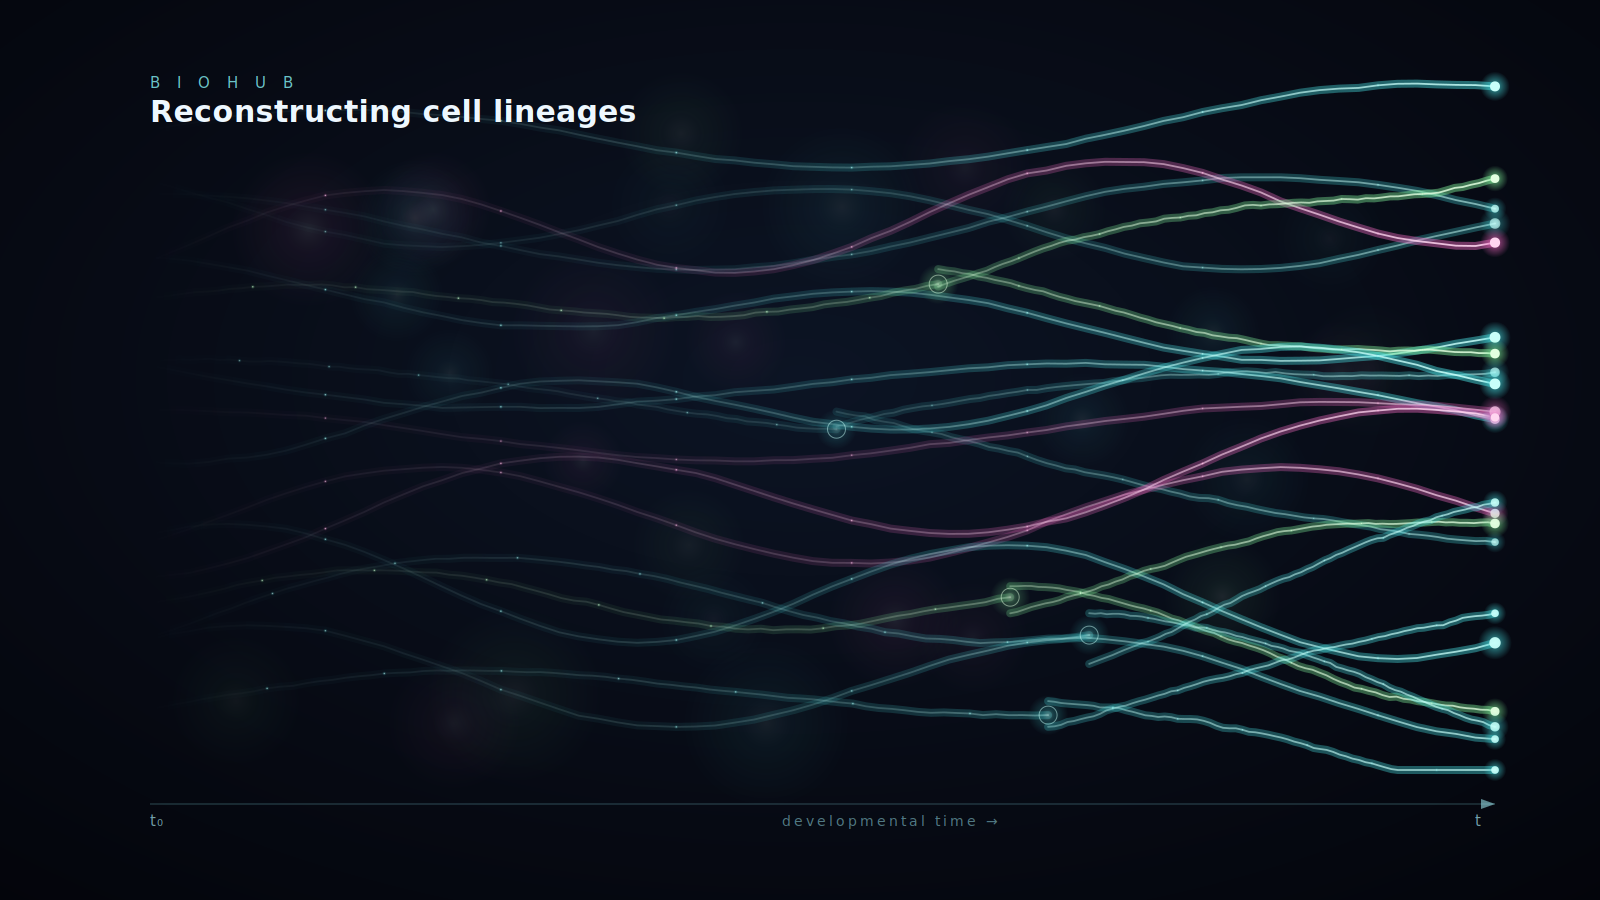

In [1]:
from pathlib import Path
from IPython.display import Image, display

cover_image_path = Path("/kaggle/input/datasets/pilkwang/pilkwang-public-dataset-for-notebooks-figures/biohub_lineage.png")
if cover_image_path.exists():
    display(Image(filename=str(cover_image_path)))

# Biohub Cell Tracking: DeepCenter Last-Checkpoint Sparse Gate
This variant targets the current late DeepCenter checkpoint directly. It uses checkpoint-last calibration computed from local sparse-label gate metrics rather than the artifact best-checkpoint summary.
The output graph uses the stricter short-track filter from the current strong graph-only baseline: connected components shorter than `7` nodes are removed unless they contain division-like branching.

The model stack is deliberately separated into three roles:

- **Backbone graph model:** `TemporalUNet3D + node transformer + ILP` from the attached learned-graph support pack.
- **Center prior:** `DeepCenterUNet3D`, loaded from `biohub-deepcenter-unet3d-center-prior-v1`, predicts an auxiliary 3D center heatmap.
- **Graph repair:** physical edge filtering, short-track component pruning, motion relinking, line-fit smoothing, and conservative division repair.

The DeepCenter model is not a replacement for the backbone. It acts as a gated proposal source for nodes that the backbone may miss.


## Modeling Logic

For a frame `t`, the learned graph backbone produces a node confidence field:

$$
p_t(r) = \sigma(h_\theta(V_t)(r))
$$

The DeepCenter prior independently produces a center heatmap:

$$
q_t(r) = \sigma(u_\phi(P(V_t))(r))
$$

Candidate centers from `q_t` are admitted only if they pass three gates:

1. heatmap confidence

$$
q_t(r) \ge \tau_c
$$

2. physical separation from existing backbone nodes

$$
d(r, D_t) \ge R_{existing}
$$

3. per-frame addition cap

$$
A_t \le \min(A_{abs}, \lceil A_{frac} \max(1, |D_t|) \rceil)
$$

Physical distance is measured in microns:

$$
d(i,j) = \sqrt{(1.625 \Delta z)^2 + (0.40625 \Delta y)^2 + (0.40625 \Delta x)^2}
$$

The fused node set is:

$$
D'_t = NMS_{um}(D_t \cup C_t, R_{nms})
$$

Edges are repaired and filtered on the fused graph. Very short connected components are removed because they usually add false positive nodes without creating useful edge matches.

For the local ep0500 `checkpoint_last.pt`, threshold `0.15` gave the best sparse-label F1 among the tested thresholds while producing only about `0.22` raw proposals per frame. The cap is intentionally small; this is a sparse high-confidence rescue path, not a broad detector replacement.
After relinking and gap repair, the short-track component filter is applied after graph repair:

$$
|C| < 7 \quad \Rightarrow \quad drop(C)=1
$$

Components with division-like branching are exempt from this rule. This stricter graph prior is inherited from the strongest graph-only public setting and is combined here with the DeepCenter center-prior gate.



In [2]:
from __future__ import annotations

import csv
import importlib.util
import json
import math
import os
import shutil
import subprocess
import tempfile
import zipfile
import sys
import time
from pathlib import Path

import pandas as pd

COMPETITION = "biohub-cell-tracking-during-development"
COMP_DIR_CANDIDATES = [
    Path(f"/kaggle/input/competitions/{COMPETITION}"),
    Path(f"/kaggle/input/{COMPETITION}"),
]
COMP_DIR = next((path for path in COMP_DIR_CANDIDATES if path.exists()), COMP_DIR_CANDIDATES[0])
_test_dir_override = os.environ.get("BIOHUB_TEST_DIR", "").strip()
TEST_DIR = Path(_test_dir_override) if _test_dir_override else COMP_DIR / "test"

WORKING_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
REPO_DIR = WORKING_DIR / "tracking_repo"
SUBMISSION_PATH = WORKING_DIR / "submission.csv"
RUN_STATS_PATH = WORKING_DIR / "run_stats.csv"

METHOD = "unet_transformer"
WEIGHTS_RELATIVE = f"weights/{METHOD}/split_0/edge_predictor_best.pth"
EXPERIMENT_TAG = "selected_30_deepcenter_500_last_sparse_gate_min7"
TARGET_ARTIFACT_SLUG = os.environ.get("BIOHUB_TARGET_ARTIFACT_SLUG", "biohub-tracking-support-pack-50ep-v1")
PRIMARY_ARTIFACT_MANIFEST = Path(os.environ.get(
    "BIOHUB_PRIMARY_ARTIFACT_MANIFEST",
    "/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/ARTIFACT_MANIFEST.json",
))
ALLOW_ARTIFACT_FALLBACK = os.environ.get("BIOHUB_ALLOW_ARTIFACT_FALLBACK", "0") != "0"

DET_THRESHOLD = float(os.environ.get("BIOHUB_DET_THRESHOLD", "0.99"))
UNET_BATCH_SIZE = int(os.environ.get("BIOHUB_UNET_BATCH_SIZE", "4"))
USE_ILP = os.environ.get("BIOHUB_USE_ILP", "1") != "0"
ILP_EDGE_WEIGHT = float(os.environ.get("BIOHUB_ILP_EDGE_WEIGHT", "-1.0"))
ILP_APPEARANCE_WEIGHT = float(os.environ.get("BIOHUB_ILP_APPEARANCE_WEIGHT", "0.1"))
ILP_DISAPPEARANCE_WEIGHT = float(os.environ.get("BIOHUB_ILP_DISAPPEARANCE_WEIGHT", "0.1"))
ILP_DIVISION_WEIGHT = float(os.environ.get("BIOHUB_ILP_DIVISION_WEIGHT", "1.0"))

# Empty for a real submission. Useful for local smoke tests, e.g. BIOHUB_SLICE=:1.
SLICE = os.environ.get("BIOHUB_SLICE", "").strip()

# If dependencies are not already installed and no offline wheels are attached,
# this controls whether the notebook attempts PyPI installation.
ALLOW_PIP_INSTALL = os.environ.get("BIOHUB_ALLOW_PIP_INSTALL", "0") != "0"
RUN_OUTPUT_DIAGNOSTICS = os.environ.get("BIOHUB_RUN_OUTPUT_DIAGNOSTICS", "1") != "0"
RUN_VISUAL_EDA = os.environ.get("BIOHUB_RUN_VISUAL_EDA", "1") != "0"

# Optional detector fusion. This stays off automatically when the support
# artifact has no weights/full_frame_center/best.pt checkpoint.
USE_FULL_FRAME_CENTER_FUSION = os.environ.get("BIOHUB_USE_FULL_FRAME_CENTER_FUSION", "1") != "0"
REQUIRE_FULL_FRAME_CENTER = os.environ.get("BIOHUB_REQUIRE_FULL_FRAME_CENTER", "1") != "0"
FULL_FRAME_CENTER_RELATIVE = os.environ.get("BIOHUB_FULL_FRAME_CENTER_RELATIVE", "weights/full_frame_center/best.pt")
FULL_FRAME_MANIFEST_DEFAULT = os.environ.get(
    "BIOHUB_FULL_FRAME_MANIFEST_DEFAULT",
    "/kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/ARTIFACT_MANIFEST.json",
)
FULL_FRAME_CHECKPOINT_DEFAULT = os.environ.get(
    "BIOHUB_FULL_FRAME_CHECKPOINT_DEFAULT",
    "/kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/weights/full_frame_center/checkpoint_last.pt",
)
FULL_FRAME_PEAK_THRESHOLD = float(os.environ.get("BIOHUB_FULL_FRAME_PEAK_THRESHOLD", "0.15"))
FULL_FRAME_MIN_PEAK_DISTANCE = int(os.environ.get("BIOHUB_FULL_FRAME_MIN_PEAK_DISTANCE", "1"))
FULL_FRAME_NMS_RADIUS_UM = float(os.environ.get("BIOHUB_FULL_FRAME_NMS_RADIUS_UM", "4.4"))
FULL_FRAME_EXISTING_GATE_UM = float(os.environ.get("BIOHUB_FULL_FRAME_EXISTING_GATE_UM", "5.0"))
FULL_FRAME_MAX_ADDED_FRAC = float(os.environ.get("BIOHUB_FULL_FRAME_MAX_ADDED_FRAC", "0.008"))
FULL_FRAME_MAX_ADDED_ABS = int(os.environ.get("BIOHUB_FULL_FRAME_MAX_ADDED_ABS", "25"))
FULL_FRAME_REFINE_CENTROIDS = os.environ.get("BIOHUB_FULL_FRAME_REFINE_CENTROIDS", "1") != "0"
FULL_FRAME_USE_GATE_CALIBRATION = os.environ.get("BIOHUB_FULL_FRAME_USE_GATE_CALIBRATION", "0") != "0"
FULL_FRAME_GATE_TARGET_PRECISION = float(os.environ.get("BIOHUB_FULL_FRAME_GATE_TARGET_PRECISION", "0.07"))
FULL_FRAME_GATE_MAX_PRED_PER_FRAME = float(os.environ.get("BIOHUB_FULL_FRAME_GATE_MAX_PRED_PER_FRAME", "0"))

# Output-level graph post-processing.
OUTPUT_EDGE_MAX_UM = float(os.environ.get("BIOHUB_OUTPUT_EDGE_MAX_UM", "14.0"))
OUTPUT_ENFORCE_NEXT_FRAME = os.environ.get("BIOHUB_OUTPUT_ENFORCE_NEXT_FRAME", "1") != "0"
OUTPUT_SINGLE_PARENT_REPAIR = os.environ.get("BIOHUB_OUTPUT_SINGLE_PARENT_REPAIR", "1") != "0"
OUTPUT_SINGLE_CHILD_REPAIR = os.environ.get("BIOHUB_OUTPUT_SINGLE_CHILD_REPAIR", "0") != "0"
OUTPUT_PRUNE_ISOLATED = os.environ.get("BIOHUB_OUTPUT_PRUNE_ISOLATED", "1") != "0"
OUTPUT_MOTION_RELINK = os.environ.get("BIOHUB_OUTPUT_MOTION_RELINK", "1") != "0"
MOTION_RELINK_TIGHT_UM = float(os.environ.get("BIOHUB_MOTION_RELINK_TIGHT_UM", "6.0"))
MOTION_RELINK_RELAXED_UM = float(os.environ.get("BIOHUB_MOTION_RELINK_RELAXED_UM", "10.0"))
MOTION_RELINK_VELOCITY_WEIGHT = float(os.environ.get("BIOHUB_MOTION_RELINK_VELOCITY_WEIGHT", "0.5"))
MOTION_RELINK_LEARNED_BONUS = float(os.environ.get("BIOHUB_MOTION_RELINK_LEARNED_BONUS", "0.75"))
MOTION_RELINK_MAX_FRAME_NODES = int(os.environ.get("BIOHUB_MOTION_RELINK_MAX_FRAME_NODES", "2600"))

OUTPUT_DIVISION_GEOMETRY_FILTER = os.environ.get("BIOHUB_OUTPUT_DIVISION_GEOMETRY_FILTER", "0") != "0"
DIV_PARENT_MAX_UM = float(os.environ.get("BIOHUB_DIV_PARENT_MAX_UM", "10.5"))
DIV_SISTER_MAX_UM = float(os.environ.get("BIOHUB_DIV_SISTER_MAX_UM", "8.0"))
DIV_DROP_TO_SINGLE_IF_BAD = os.environ.get("BIOHUB_DIV_DROP_TO_SINGLE_IF_BAD", "1") != "0"
OUTPUT_GAP_CLOSE = os.environ.get("BIOHUB_OUTPUT_GAP_CLOSE", "1") != "0"
GAP_CLOSE_MAX_GAP = int(os.environ.get("BIOHUB_GAP_CLOSE_MAX_GAP", "1"))
GAP_CLOSE_UM = float(os.environ.get("BIOHUB_GAP_CLOSE_UM", "6.0"))
GAP_CLOSE_REUSE_EXISTING = os.environ.get("BIOHUB_GAP_CLOSE_REUSE_EXISTING", "1") != "0"
GAP_CLOSE_REUSE_UM = float(os.environ.get("BIOHUB_GAP_CLOSE_REUSE_UM", "3.2"))
GAP_CLOSE_MAX_ADDED_FRAC = float(os.environ.get("BIOHUB_GAP_CLOSE_MAX_ADDED_FRAC", "0.05"))
GAP_CLOSE_MAX_ADDED_ABS = int(os.environ.get("BIOHUB_GAP_CLOSE_MAX_ADDED_ABS", "2000"))
GAP_REFINE_SYNTHETIC = os.environ.get("BIOHUB_GAP_REFINE_SYNTHETIC", "1") != "0"
GAP_REFINE_WIN_Z = int(os.environ.get("BIOHUB_GAP_REFINE_WIN_Z", "1"))
GAP_REFINE_WIN_YX = int(os.environ.get("BIOHUB_GAP_REFINE_WIN_YX", "3"))
GAP_REFINE_MAX_SHIFT_UM = float(os.environ.get("BIOHUB_GAP_REFINE_MAX_SHIFT_UM", "3.2"))

OUTPUT_FILTER_SHORT_TRACKS = os.environ.get("BIOHUB_OUTPUT_FILTER_SHORT_TRACKS", "1") != "0"
OUTPUT_MIN_TRACK_LEN = int(os.environ.get("BIOHUB_OUTPUT_MIN_TRACK_LEN", "7"))
OUTPUT_KEEP_DIVISION_COMPONENTS = os.environ.get("BIOHUB_OUTPUT_KEEP_DIVISION_COMPONENTS", "1") != "0"

OUTPUT_LINEFIT_SMOOTH = os.environ.get("BIOHUB_OUTPUT_LINEFIT_SMOOTH", "1") != "0"
OUTPUT_LINEFIT_WEIGHT = float(os.environ.get("BIOHUB_OUTPUT_LINEFIT_WEIGHT", "0.8"))
OUTPUT_LINEFIT_WINDOW = int(os.environ.get("BIOHUB_OUTPUT_LINEFIT_WINDOW", "2"))

OUTPUT_GAP2_RECOVERY = os.environ.get("BIOHUB_OUTPUT_GAP2_RECOVERY", "0") != "0"
GAP2_MAX_TOTAL_UM = float(os.environ.get("BIOHUB_GAP2_MAX_TOTAL_UM", "10.2"))
GAP2_MAX_STEP_UM = float(os.environ.get("BIOHUB_GAP2_MAX_STEP_UM", "4.4"))
GAP2_MAX_LINKS_FRAC = float(os.environ.get("BIOHUB_GAP2_MAX_LINKS_FRAC", "0.0045"))
GAP2_MAX_LINKS_ABS = int(os.environ.get("BIOHUB_GAP2_MAX_LINKS_ABS", "180"))
GAP2_REQUIRE_CONTEXT = os.environ.get("BIOHUB_GAP2_REQUIRE_CONTEXT", "1") != "0"
GAP2_FRAME_FRAC_CAP = float(os.environ.get("BIOHUB_GAP2_FRAME_FRAC_CAP", "0.006"))

OUTPUT_SAFE_DIVISIONS = os.environ.get("BIOHUB_OUTPUT_SAFE_DIVISIONS", "1") != "0"
SAFE_DIV_MAX_UM = float(os.environ.get("BIOHUB_SAFE_DIV_MAX_UM", "4.7"))
SAFE_DIV_SISTER_MAX_UM = float(os.environ.get("BIOHUB_SAFE_DIV_SISTER_MAX_UM", "7.2"))
SAFE_DIV_EXISTING_CHILD_MAX_UM = float(os.environ.get("BIOHUB_SAFE_DIV_EXISTING_CHILD_MAX_UM", "7.8"))
SAFE_DIV_FRAME_FRAC_CAP = float(os.environ.get("BIOHUB_SAFE_DIV_FRAME_FRAC_CAP", "0.008"))
SAFE_DIV_GLOBAL_FRAC_CAP = float(os.environ.get("BIOHUB_SAFE_DIV_GLOBAL_FRAC_CAP", "0.004"))

CONFIG_DISPLAY = {
    "experiment_tag": EXPERIMENT_TAG,
    "method": METHOD,
    "weights": WEIGHTS_RELATIVE,
    "target_artifact_slug": TARGET_ARTIFACT_SLUG,
    "primary_artifact_manifest": str(PRIMARY_ARTIFACT_MANIFEST),
    "allow_artifact_fallback": ALLOW_ARTIFACT_FALLBACK,
    "det_threshold": DET_THRESHOLD,
    "unet_batch_size": UNET_BATCH_SIZE,
    "use_ilp": USE_ILP,
    "ilp_edge_weight": ILP_EDGE_WEIGHT,
    "ilp_appearance_weight": ILP_APPEARANCE_WEIGHT,
    "ilp_disappearance_weight": ILP_DISAPPEARANCE_WEIGHT,
    "ilp_division_weight": ILP_DIVISION_WEIGHT,
    "slice": SLICE,
    "allow_pip_install": ALLOW_PIP_INSTALL,
    "run_visual_eda": RUN_VISUAL_EDA,
    "use_full_frame_center_fusion": USE_FULL_FRAME_CENTER_FUSION,
    "require_full_frame_center": REQUIRE_FULL_FRAME_CENTER,
    "full_frame_center_relative": FULL_FRAME_CENTER_RELATIVE,
    "full_frame_manifest_default": FULL_FRAME_MANIFEST_DEFAULT,
    "full_frame_checkpoint_default": FULL_FRAME_CHECKPOINT_DEFAULT,
    "full_frame_peak_threshold": FULL_FRAME_PEAK_THRESHOLD,
    "full_frame_min_peak_distance": FULL_FRAME_MIN_PEAK_DISTANCE,
    "full_frame_nms_radius_um": FULL_FRAME_NMS_RADIUS_UM,
    "full_frame_existing_gate_um": FULL_FRAME_EXISTING_GATE_UM,
    "full_frame_max_added_frac": FULL_FRAME_MAX_ADDED_FRAC,
    "full_frame_max_added_abs": FULL_FRAME_MAX_ADDED_ABS,
    "full_frame_refine_centroids": FULL_FRAME_REFINE_CENTROIDS,
    "full_frame_use_gate_calibration": FULL_FRAME_USE_GATE_CALIBRATION,
    "full_frame_gate_target_precision": FULL_FRAME_GATE_TARGET_PRECISION,
    "full_frame_gate_max_pred_per_frame": FULL_FRAME_GATE_MAX_PRED_PER_FRAME,
    "output_edge_max_um": OUTPUT_EDGE_MAX_UM,
    "output_enforce_next_frame": OUTPUT_ENFORCE_NEXT_FRAME,
    "output_single_parent_repair": OUTPUT_SINGLE_PARENT_REPAIR,
    "output_single_child_repair": OUTPUT_SINGLE_CHILD_REPAIR,
    "output_prune_isolated": OUTPUT_PRUNE_ISOLATED,
    "output_motion_relink": OUTPUT_MOTION_RELINK,
    "motion_relink_tight_um": MOTION_RELINK_TIGHT_UM,
    "motion_relink_relaxed_um": MOTION_RELINK_RELAXED_UM,
    "motion_relink_velocity_weight": MOTION_RELINK_VELOCITY_WEIGHT,
    "motion_relink_learned_bonus": MOTION_RELINK_LEARNED_BONUS,
    "motion_relink_max_frame_nodes": MOTION_RELINK_MAX_FRAME_NODES,
    "output_division_geometry_filter": OUTPUT_DIVISION_GEOMETRY_FILTER,
    "div_parent_max_um": DIV_PARENT_MAX_UM,
    "div_sister_max_um": DIV_SISTER_MAX_UM,
    "div_drop_to_single_if_bad": DIV_DROP_TO_SINGLE_IF_BAD,
    "output_gap_close": OUTPUT_GAP_CLOSE,
    "gap_close_max_gap": GAP_CLOSE_MAX_GAP,
    "gap_close_effective_max_gap": min(GAP_CLOSE_MAX_GAP, 1),
    "gap_close_um": GAP_CLOSE_UM,
    "gap_close_reuse_existing": GAP_CLOSE_REUSE_EXISTING,
    "gap_close_reuse_um": GAP_CLOSE_REUSE_UM,
    "gap_close_max_added_frac": GAP_CLOSE_MAX_ADDED_FRAC,
    "gap_close_max_added_abs": GAP_CLOSE_MAX_ADDED_ABS,
    "gap_refine_synthetic": GAP_REFINE_SYNTHETIC,
    "gap_refine_win_z": GAP_REFINE_WIN_Z,
    "gap_refine_win_yx": GAP_REFINE_WIN_YX,
    "gap_refine_max_shift_um": GAP_REFINE_MAX_SHIFT_UM,
    "output_filter_short_tracks": OUTPUT_FILTER_SHORT_TRACKS,
    "output_min_track_len": OUTPUT_MIN_TRACK_LEN,
    "output_keep_division_components": OUTPUT_KEEP_DIVISION_COMPONENTS,
    "output_linefit_smooth": OUTPUT_LINEFIT_SMOOTH,
    "output_linefit_weight": OUTPUT_LINEFIT_WEIGHT,
    "output_linefit_window": OUTPUT_LINEFIT_WINDOW,
    "output_gap2_recovery": OUTPUT_GAP2_RECOVERY,
    "gap2_max_total_um": GAP2_MAX_TOTAL_UM,
    "gap2_max_step_um": GAP2_MAX_STEP_UM,
    "gap2_max_links_frac": GAP2_MAX_LINKS_FRAC,
    "gap2_max_links_abs": GAP2_MAX_LINKS_ABS,
    "gap2_require_context": GAP2_REQUIRE_CONTEXT,
    "gap2_frame_frac_cap": GAP2_FRAME_FRAC_CAP,
    "output_safe_divisions": OUTPUT_SAFE_DIVISIONS,
    "safe_div_max_um": SAFE_DIV_MAX_UM,
    "safe_div_sister_max_um": SAFE_DIV_SISTER_MAX_UM,
    "safe_div_existing_child_max_um": SAFE_DIV_EXISTING_CHILD_MAX_UM,
    "safe_div_frame_frac_cap": SAFE_DIV_FRAME_FRAC_CAP,
    "safe_div_global_frac_cap": SAFE_DIV_GLOBAL_FRAC_CAP,
}

print("Biohub learned UNet + node-transformer + ILP submission")
print("COMP_DIR:", COMP_DIR, "exists:", COMP_DIR.exists())
print("TEST_DIR:", TEST_DIR, "exists:", TEST_DIR.exists())
print(json.dumps(CONFIG_DISPLAY, indent=2, sort_keys=True))

Biohub learned UNet + node-transformer + ILP submission
COMP_DIR: /kaggle/input/competitions/biohub-cell-tracking-during-development exists: True
TEST_DIR: /kaggle/input/competitions/biohub-cell-tracking-during-development/test exists: True
{
  "allow_artifact_fallback": false,
  "allow_pip_install": false,
  "det_threshold": 0.99,
  "div_drop_to_single_if_bad": true,
  "div_parent_max_um": 10.5,
  "div_sister_max_um": 8.0,
  "experiment_tag": "selected_30_deepcenter_500_last_sparse_gate_min7",
  "full_frame_center_relative": "weights/full_frame_center/best.pt",
  "full_frame_checkpoint_default": "/kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/weights/full_frame_center/checkpoint_last.pt",
  "full_frame_existing_gate_um": 5.0,
  "full_frame_gate_max_pred_per_frame": 0.0,
  "full_frame_gate_target_precision": 0.07,
  "full_frame_manifest_default": "/kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/ARTIFACT_MANIFEST.json",
  "full_frame_max_added_abs": 25,
  "full_frame_max_

## Model Artifacts and Dependencies

This notebook expects two Kaggle datasets to be attached:

- learned graph support pack: `/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/ARTIFACT_MANIFEST.json`
- DeepCenter prior manifest: `/kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/ARTIFACT_MANIFEST.json`
- DeepCenter checkpoint default: `/kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/weights/full_frame_center/checkpoint_last.pt`

The DeepCenter dataset version can be changed in the Kaggle UI to compare different snapshot uploads. This variant is configured for the last checkpoint from the attached artifact.

Runtime dependency handling uses already installed packages first, then attached wheels. Internet installation is disabled by default.


In [3]:
import re

os.environ.setdefault("POLARS_PREFER_PKG", "32")

PACKAGE_SPECS = {
    "tracksdata": ("tracksdata", "tracksdata"),
    "zarr": ("zarr", "zarr>=3.0.10,<4"),
    "pyscipopt": ("pyscipopt", "pyscipopt"),
    "geff": ("geff", "geff>=1.1.3.1.1"),
    "geff_spec": ("geff_spec", "geff-spec<1.2"),
    "ilpy": ("ilpy", "ilpy>=0.5.1"),
    "polars": ("polars", "polars>=1.36"),
    "blosc2": ("blosc2", "blosc2"),
    "dask": ("dask", "dask"),
    "imagecodecs": ("imagecodecs", "imagecodecs"),
    "skimage": ("skimage", "scikit-image>=0.24"),
    "pyarrow": ("pyarrow", "pyarrow"),
    "rustworkx": ("rustworkx", "rustworkx>=0.17.1"),
    "sqlalchemy": ("sqlalchemy", "sqlalchemy>=2"),
    "numcodecs": ("numcodecs", "numcodecs>=0.13,<0.16"),
    "donfig": ("donfig", "donfig>=0.8"),
    "google_crc32c": ("google_crc32c", "google-crc32c>=1.5"),
    "bidict": ("bidict", "bidict>=0.23.1"),
    "psygnal": ("psygnal", "psygnal>=0.14"),
    "rich": ("rich", "rich"),
    "networkx": ("networkx", "networkx>=3.2.1"),
    "pydantic": ("pydantic", "pydantic>=2.11"),
    "pydantic_core": ("pydantic_core", "pydantic-core"),
    "annotated_types": ("annotated_types", "annotated-types"),
    "typing_extensions": ("typing_extensions", "typing-extensions>=4.13"),
    "typing_inspection": ("typing_inspection", "typing-inspection"),
    "markdown_it": ("markdown_it", "markdown-it-py"),
    "pygments": ("pygments", "pygments"),
    "click": ("click", "click"),
    "cloudpickle": ("cloudpickle", "cloudpickle"),
    "fsspec": ("fsspec", "fsspec"),
    "partd": ("partd", "partd"),
    "locket": ("locket", "locket"),
    "toolz": ("toolz", "toolz"),
    "yaml": ("yaml", "pyyaml"),
    "ndindex": ("ndindex", "ndindex"),
    "msgpack": ("msgpack", "msgpack"),
    "numexpr": ("numexpr", "numexpr"),
    "deprecated": ("deprecated", "deprecated"),
    "wrapt": ("wrapt", "wrapt"),
    "imageio": ("imageio", "imageio"),
    "PIL": ("PIL", "pillow"),
    "tifffile": ("tifffile", "tifffile"),
    "lazy_loader": ("lazy_loader", "lazy-loader"),
    "tqdm": ("tqdm", "tqdm"),
}
EXTRA_SPECS_BY_NAME = {
    "tracksdata": ["bidict>=0.23.1", "psygnal>=0.14", "rich"],
    "zarr": ["donfig>=0.8", "google-crc32c>=1.5", "numcodecs>=0.13,<0.16"],
    "geff": ["geff-spec<1.2", "networkx>=3.2.1", "pydantic>=2.11", "numcodecs>=0.13,<0.16"],
    "geff_spec": ["pydantic>=2.11", "annotated-types", "pydantic-core", "typing-inspection"],
    "polars": ["polars-runtime-32"],
    "dask": ["click", "cloudpickle", "fsspec", "partd", "pyyaml", "toolz"],
    "partd": ["locket"],
    "blosc2": ["ndindex", "msgpack", "numexpr"],
    "numcodecs": ["deprecated", "msgpack", "wrapt"],
    "rich": ["markdown-it-py", "pygments"],
    "pydantic": ["annotated-types", "pydantic-core", "typing-extensions>=4.13", "typing-inspection"],
    "skimage": ["imageio", "pillow", "tifffile", "lazy-loader", "networkx"],
}
PIP_DEPENDENCIES = [spec for _, spec in PACKAGE_SPECS.values()]
REQUIRED_MODULES = {name: module for name, (module, _) in PACKAGE_SPECS.items() if module}
FALLBACK_ARTIFACT_SLUGS = ["biohub-tracking-support-pack-v1"]

# The safe path for offline reruns is to use attached wheels.
# Set BIOHUB_ALLOW_PIP_INSTALL=1 only for an interactive internet-enabled run.
ALLOW_PIP_INSTALL = os.environ.get("BIOHUB_ALLOW_PIP_INSTALL", "0") != "0"


def module_missing(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is None


def has_model_artifact(path: Path) -> bool:
    has_repo_dir = (path / "repo").exists()
    has_weights_dir = (path / "weights" / METHOD / "split_0" / "edge_predictor_best.pth").exists()
    has_repo_zip = (path / "repo.zip").exists()
    has_weights_zip = (path / "weights.zip").exists()
    return (has_repo_dir and has_weights_dir) or (has_repo_zip and has_weights_zip)


def artifact_manifest(path: Path) -> dict:
    manifest = path / "ARTIFACT_MANIFEST.json"
    if not manifest.exists():
        return {}
    try:
        return json.loads(manifest.read_text())
    except Exception:
        return {}


def artifact_matches_target(path: Path) -> bool:
    if ALLOW_ARTIFACT_FALLBACK:
        return True
    manifest = artifact_manifest(path)
    artifact_name = str(manifest.get("artifact_name", ""))
    path_text = str(path)
    return TARGET_ARTIFACT_SLUG in {artifact_name, path.name} or TARGET_ARTIFACT_SLUG in path_text


def candidate_roots_for_slug(slug: str) -> list[Path]:
    return [
        Path(f"/kaggle/input/datasets/pilkwang/{slug}"),
        Path(f"/kaggle/input/{slug}"),
        Path(f"/kaggle/input/{slug}/{slug}"),
        Path(f"PublicNotebook/{slug}"),
    ]


def find_artifacts_root() -> Path:
    candidates: list[Path] = []
    for env_name in ["BIOHUB_MODEL_ARTIFACTS", "BIOHUB_ARTIFACTS"]:
        explicit = os.environ.get(env_name, "").strip()
        if explicit:
            candidates.append(Path(explicit))

    candidates.append(PRIMARY_ARTIFACT_MANIFEST.parent)
    candidates.extend(candidate_roots_for_slug(TARGET_ARTIFACT_SLUG))

    if ALLOW_ARTIFACT_FALLBACK:
        for slug in FALLBACK_ARTIFACT_SLUGS:
            candidates.extend(candidate_roots_for_slug(slug))

    input_root = Path("/kaggle/input")
    if input_root.exists():
        for child in input_root.iterdir():
            if not child.is_dir():
                continue
            child_text = str(child)
            if TARGET_ARTIFACT_SLUG in child_text or ALLOW_ARTIFACT_FALLBACK:
                candidates.append(child)
                candidates.append(child / child.name)
                for grandchild in child.iterdir():
                    if grandchild.is_dir():
                        candidates.append(grandchild)

    seen: set[Path] = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        if candidate in seen:
            continue
        seen.add(candidate)
        if has_model_artifact(candidate) and artifact_matches_target(candidate):
            return candidate
    checked = "\n".join(str(path) for path in candidates[:80])
    raise FileNotFoundError(
        "Could not find the required model artifact. "
        f"Expected slug: {TARGET_ARTIFACT_SLUG}\n"
        "Attach the newly uploaded support dataset, or set BIOHUB_MODEL_ARTIFACTS.\n"
        "To debug with an older artifact, set BIOHUB_ALLOW_ARTIFACT_FALLBACK=1.\n"
        "Checked:\n" + checked
    )


def _has_package_file(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    patterns = ("*.whl", "*.tar.gz", "*.zip")
    return any(any(path.glob(pattern)) for pattern in patterns)


def find_offline_package_dirs(artifacts: Path) -> list[Path]:
    candidates: list[Path] = [
        artifacts / "wheels",
        artifacts,
        Path("/kaggle/working"),
        Path("/kaggle/working/wheels"),
    ]
    input_root = Path("/kaggle/input")
    if input_root.exists():
        for child in input_root.iterdir():
            if child.is_dir():
                candidates.extend([child / "wheels", child])
                for grandchild in child.iterdir():
                    if grandchild.is_dir():
                        candidates.extend([grandchild / "wheels", grandchild])

    out: list[Path] = []
    seen: set[Path] = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        if candidate in seen:
            continue
        seen.add(candidate)
        if _has_package_file(candidate):
            out.append(candidate)
    return out


def purge_imported_modules(package_names: list[str]) -> None:
    roots = {"tracksdata"}
    for name in package_names:
        if name in PACKAGE_SPECS:
            module = PACKAGE_SPECS[name][0]
            roots.add(module.split(".")[0])
        if name == "polars":
            roots.add("polars")
    for root in roots:
        for module_name in list(sys.modules):
            if module_name == root or module_name.startswith(root + "."):
                sys.modules.pop(module_name, None)


def polars_runtime_ready() -> bool:
    try:
        import polars as _pl
        from polars._plr import PySeries as _PySeries

        _ = _PySeries
        return hasattr(_pl, "Float16") and _pl.Series([-999999.0], dtype=_pl.Float64).dtype == _pl.Float64
    except Exception:
        return False


def packages_requiring_refresh() -> list[str]:
    refresh: list[str] = []
    if not module_missing("polars") and not polars_runtime_ready():
        refresh.append("polars")

    if not module_missing("zarr"):
        try:
            import zarr as _zarr
            version_text = str(getattr(_zarr, "__version__", "0"))
            major = int(version_text.split(".", 1)[0])
            if major < 3:
                refresh.append("zarr")
        except Exception:
            refresh.append("zarr")
    return refresh


def dependency_specs_for(missing: list[str]) -> list[str]:
    specs: list[str] = []
    seen: set[str] = set()

    def add(spec: str) -> None:
        key = spec.lower()
        if key not in seen:
            seen.add(key)
            specs.append(spec)

    for name in missing:
        if name in PACKAGE_SPECS:
            add(PACKAGE_SPECS[name][1])
        for spec in EXTRA_SPECS_BY_NAME.get(name, []):
            add(spec)
    return specs


def import_failures() -> dict[str, str]:
    failures: dict[str, str] = {}
    for name, module_name in REQUIRED_MODULES.items():
        try:
            importlib.import_module(module_name)
        except Exception as exc:
            failures[name] = f"{type(exc).__name__}: {exc}"
    return failures


def missing_names_from_failures(failures: dict[str, str]) -> list[str]:
    names: list[str] = []
    module_to_name = {module: name for name, module in REQUIRED_MODULES.items()}
    for message in failures.values():
        match = re.search(r"No module named ['\"]([^'\"]+)['\"]", message)
        if match:
            module = match.group(1).split(".")[0]
        else:
            match = re.search(r"module ['\"]([^'\"]+)['\"] has no attribute", message)
            if not match:
                continue
            module = match.group(1).split(".")[0]
        name = module_to_name.get(module)
        if name and name not in names:
            names.append(name)
    return names


def install_missing_dependencies(missing: list[str], artifacts: Path) -> None:
    specs = dependency_specs_for(missing)
    force_reinstall = bool({"polars", "zarr"} & set(missing))
    if not specs:
        return

    package_dirs = find_offline_package_dirs(artifacts)
    if package_dirs:
        offline_cmd = [sys.executable, "-m", "pip", "install", "--no-index", "--no-deps"]
        if force_reinstall:
            offline_cmd.append("--force-reinstall")
        for package_dir in package_dirs:
            offline_cmd.extend(["--find-links", str(package_dir)])
        offline_cmd.extend(specs)
        print("Installing missing packages from offline package dirs:", missing)
        print("Dependency resolver is disabled with --no-deps to avoid replacing Kaggle numpy/scipy in a live kernel.")
        print("Offline package dirs:", [str(path) for path in package_dirs])
        result = subprocess.run(offline_cmd, text=True, capture_output=True)
        if result.returncode == 0:
            purge_imported_modules(missing)
            print("Offline dependency install succeeded.")
            return
        print("Offline dependency install failed. Last pip output:")
        print((result.stdout or "")[-2000:])
        print((result.stderr or "")[-2000:])

    if ALLOW_PIP_INSTALL:
        online_cmd = [sys.executable, "-m", "pip", "install", "--no-deps"]
        if force_reinstall:
            online_cmd.append("--force-reinstall")
        online_cmd.extend(specs)
        print("Installing missing packages from PyPI:", missing)
        result = subprocess.run(online_cmd, text=True, capture_output=True)
        if result.returncode == 0:
            purge_imported_modules(missing)
            print("PyPI dependency install succeeded.")
            return
        print("PyPI dependency install failed. Last pip output:")
        print((result.stdout or "")[-2000:])
        print((result.stderr or "")[-2000:])

    command = "pip install tracksdata zarr>=3.0.10,<4 pyscipopt geff geff-spec ilpy polars blosc2 dask imagecodecs pyarrow rustworkx sqlalchemy donfig numcodecs"
    raise ImportError(
        "Missing required packages or dependency wheels: " + ", ".join(missing) + "\n"
        "Attach the support dataset with offline wheels. If supplying Kaggle dependency input instead, use:\n"
        + command + "\n"
        "Do not quote zarr>=3.0.10,<4 in Kaggle dependency input."
    )


def ensure_dependencies(artifacts: Path) -> None:
    for _ in range(5):
        refresh = packages_requiring_refresh()
        if refresh:
            install_missing_dependencies(refresh, artifacts)
            continue

        missing = [pkg for pkg, module in REQUIRED_MODULES.items() if module_missing(module)]
        if missing:
            install_missing_dependencies(missing, artifacts)
            continue

        failures = import_failures()
        if not failures:
            print("Required graph/Zarr/ILP packages import successfully.")
            return

        missing_from_import = missing_names_from_failures(failures)
        if missing_from_import:
            install_missing_dependencies(missing_from_import, artifacts)
            continue

        raise ImportError(
            "Required packages are present but failed to import. "
            "This may indicate a binary dependency mismatch in the live notebook kernel. "
            "Keep Kaggle dependency input empty and attach the wheels artifact.\n"
            + json.dumps(failures, indent=2)
        )

    failures = import_failures()
    raise ImportError(
        "Dependency recovery did not converge after repeated offline installs. "
        "The attached support artifact may be missing wheels.\n"
        + json.dumps(failures, indent=2)
    )


def remove_path(path: Path) -> None:
    if path.is_symlink() or path.is_file():
        path.unlink()
    elif path.exists():
        shutil.rmtree(path)


def copy_or_extract_tree(src_dir: Path, src_zip: Path, dst: Path) -> None:
    remove_path(dst)
    if src_dir.exists() and src_dir.is_dir():
        shutil.copytree(src_dir, dst)
        return
    if src_zip.exists() and src_zip.is_file():
        dst.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(src_zip) as zf:
            zf.extractall(dst)
        return
    raise FileNotFoundError(f"Missing source tree or zip: {src_dir} / {src_zip}")


def link_or_copy_tree(src: Path, dst: Path) -> None:
    remove_path(dst)
    try:
        os.symlink(src, dst, target_is_directory=True)
    except Exception:
        shutil.copytree(src, dst)


def materialize_inference_repo(artifacts: Path) -> None:
    copy_or_extract_tree(artifacts / "repo", artifacts / "repo.zip", REPO_DIR)

    weights_src = artifacts / "weights"
    weights_zip = artifacts / "weights.zip"
    weights_dst = REPO_DIR / "weights"
    if weights_src.exists() and weights_src.is_dir():
        link_or_copy_tree(weights_src, weights_dst)
    elif weights_zip.exists() and weights_zip.is_file():
        remove_path(weights_dst)
        weights_dst.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(weights_zip) as zf:
            zf.extractall(weights_dst)
    else:
        raise FileNotFoundError(f"Missing weights tree or zip under {artifacts}")

    required = [
        REPO_DIR / "scripts" / "predict_unet_transformer.py",
        REPO_DIR / WEIGHTS_RELATIVE,
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError("Materialized inference repo is incomplete:\n" + "\n".join(missing))
    print("Inference repo:", REPO_DIR)
    print("Weights:", REPO_DIR / WEIGHTS_RELATIVE)


ARTIFACTS = find_artifacts_root()
print("ARTIFACTS:", ARTIFACTS)
print("Has offline wheels:", (ARTIFACTS / "wheels").exists())
manifest_info = artifact_manifest(ARTIFACTS)
if manifest_info:
    print("Artifact name:", manifest_info.get("artifact_name"))
    print("Weight sha256:", manifest_info.get("model", {}).get("weight_sha256"))
    print("Weight path:", manifest_info.get("model", {}).get("weight_path"))

ensure_dependencies(ARTIFACTS)
materialize_inference_repo(ARTIFACTS)


ARTIFACTS: /kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1
Has offline wheels: True
Artifact name: biohub-tracking-support-pack-300ep-snapshot-v1
Weight sha256: 12b5d32ad8982e4736f74c41bc54403094917fe75f5a9f78b1b5aad41de26877
Weight path: weights/unet_transformer/split_0/edge_predictor_best.pth
Installing missing packages from offline package dirs: ['polars']
Dependency resolver is disabled with --no-deps to avoid replacing Kaggle numpy/scipy in a live kernel.
Offline package dirs: ['/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/wheels']
Offline dependency install succeeded.
Installing missing packages from offline package dirs: ['tracksdata', 'zarr', 'pyscipopt', 'geff', 'geff_spec', 'ilpy', 'imagecodecs', 'rustworkx', 'numcodecs', 'donfig', 'bidict']
Dependency resolver is disabled with --no-deps to avoid replacing Kaggle numpy/scipy in a live kernel.
Offline package dirs: ['/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-

/usr/local/lib/python3.12/dist-packages/dask/array/image.py:7: FutureWarning: `find_available_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  from skimage.io import imread as sk_imread
/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `reset_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  return _bootstrap._gcd_import(name[level:], package, level)


Required graph/Zarr/ILP packages import successfully.
Inference repo: /kaggle/working/tracking_repo
Weights: /kaggle/working/tracking_repo/weights/unet_transformer/split_0/edge_predictor_best.pth


## Predict Candidate Graphs

Each hidden-test video is converted into a `.geff` candidate graph. The backbone produces the initial graph; the DeepCenter center prior can add gated nodes before output-level graph repair.


In [4]:
def list_test_stems() -> list[str]:
    if not TEST_DIR.exists():
        raise FileNotFoundError(f"Test directory does not exist: {TEST_DIR}")
    stems = sorted(path.name[:-5] for path in TEST_DIR.iterdir() if path.name.endswith(".zarr"))
    if not stems:
        raise FileNotFoundError(f"No test .zarr files found in {TEST_DIR}")
    return stems


test_stems = list_test_stems()
print(f"Found {len(test_stems)} test videos")
print(test_stems[:10])

splits_path = REPO_DIR / "kaggle_test_splits_50ep.json"
splits_path.parent.mkdir(parents=True, exist_ok=True)
splits_path.write_text(json.dumps([{"split": 0, "train": [], "test": test_stems}], indent=2))

predict_cmd = [
    sys.executable,
    "scripts/predict_unet_transformer.py",
    "--data-dir",
    str(TEST_DIR),
    "--splits",
    str(splits_path.name),
    "--split",
    "0",
    "--weights",
    WEIGHTS_RELATIVE,
    "--unet-batch-size",
    str(UNET_BATCH_SIZE),
    "--det-threshold",
    str(DET_THRESHOLD),
    "--ilp-edge-weight",
    str(ILP_EDGE_WEIGHT),
    "--ilp-appearance-weight",
    str(ILP_APPEARANCE_WEIGHT),
    "--ilp-disappearance-weight",
    str(ILP_DISAPPEARANCE_WEIGHT),
    "--ilp-division-weight",
    str(ILP_DIVISION_WEIGHT),
]
if USE_ILP:
    predict_cmd.append("--use-ilp")
if SLICE:
    predict_cmd.extend(["--slice", SLICE])

start_time = time.time()
print(" ".join(predict_cmd))
subprocess.run(predict_cmd, cwd=REPO_DIR, env={**os.environ, "PYTHONPATH": "src"}, check=True)
predict_seconds = time.time() - start_time
print(f"Prediction completed in {predict_seconds / 60:.2f} minutes")


Found 4 test videos
['44b6_0113de3b', '44b6_0b24845f', '6bba_05b6850b', '6bba_05db0fb1']
/usr/bin/python3 scripts/predict_unet_transformer.py --data-dir /kaggle/input/competitions/biohub-cell-tracking-during-development/test --splits kaggle_test_splits_50ep.json --split 0 --weights weights/unet_transformer/split_0/edge_predictor_best.pth --unet-batch-size 4 --det-threshold 0.99 --ilp-edge-weight -1.0 --ilp-appearance-weight 0.1 --ilp-disappearance-weight 0.1 --ilp-division-weight 1.0 --use-ilp


/usr/local/lib/python3.12/dist-packages/dask/array/image.py:7: FutureWarning: `find_available_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  from skimage.io import imread as sk_imread
/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `reset_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  return _bootstrap._gcd_import(name[level:], package, level)


Fold 0: 4 datasets | weights=weights/unet_transformer/split_0/edge_predictor_best.pth | device=cuda | window_size=2 | pool_kernel_um=3.0
Saved 4 predictions to /kaggle/working/tracking_repo/predictions/unknown/unet_transformer/split_0
Prediction completed in 6.10 minutes


## Build `submission.csv`

The final graph is streamed directly into the required CSV schema:

`id,dataset,row_type,node_id,t,z,y,x,source_id,target_id`

Node rows contain integer voxel centroids, while edge rows reference source and target node IDs. The audit step checks that every test dataset appears and that edge endpoints refer to valid nodes.


In [5]:
import tracksdata as td
import numpy as np
import blosc2
import torch
from scipy.optimize import linear_sum_assignment

SUBMISSION_COLUMNS = ["dataset", "row_type", "node_id", "t", "z", "y", "x", "source_id", "target_id"]
CSV_COLUMNS = ["id", *SUBMISSION_COLUMNS]
VOXEL_SCALE_UM = (1.625, 0.40625, 0.40625)


def graph_from_geff(path: Path):
    graph = td.graph.IndexedRXGraph.from_geff(path)
    return graph[0] if isinstance(graph, tuple) else graph


def edge_distance_um(source: dict[str, object], target: dict[str, object]) -> float:
    dz = (float(source["z"]) - float(target["z"])) * VOXEL_SCALE_UM[0]
    dy = (float(source["y"]) - float(target["y"])) * VOXEL_SCALE_UM[1]
    dx = (float(source["x"]) - float(target["x"])) * VOXEL_SCALE_UM[2]
    return math.sqrt(dz * dz + dy * dy + dx * dx)


def point_distance_um(a: tuple[float, float, float], b: tuple[float, float, float]) -> float:
    dz = (a[0] - b[0]) * VOXEL_SCALE_UM[0]
    dy = (a[1] - b[1]) * VOXEL_SCALE_UM[1]
    dx = (a[2] - b[2]) * VOXEL_SCALE_UM[2]
    return math.sqrt(dz * dz + dy * dy + dx * dx)


def node_point(node: dict[str, object]) -> tuple[float, float, float]:
    return (float(node["z"]), float(node["y"]), float(node["x"]))


def edge_sort_key(edge: dict[str, object]) -> tuple[float, float]:
    prob = edge.get("edge_prob")
    prob_value = float(prob) if prob is not None else 0.0
    return prob_value, -float(edge["distance_um"])


def _next_node_id(nodes_by_id: dict[int, dict[str, object]]) -> int:
    return max(nodes_by_id) + 1 if nodes_by_id else 1


def _ff_pool_frame_xy(volume: np.ndarray, factor: int) -> np.ndarray:
    if factor <= 1:
        return volume.astype(np.float32, copy=False)
    z, y, x = volume.shape
    y2 = (y // factor) * factor
    x2 = (x // factor) * factor
    cropped = volume[:, :y2, :x2].astype(np.float32, copy=False)
    return cropped.reshape(z, y2 // factor, factor, x2 // factor, factor).mean(axis=(2, 4))


def _ff_normalize_dynamic_range(volume: np.ndarray, cfg: object) -> np.ndarray:
    vol = np.asarray(volume, dtype=np.float32)
    lo = float(np.percentile(vol, float(getattr(cfg, "norm_lo_pct", 50.0))))
    hi = float(np.percentile(vol, float(getattr(cfg, "norm_hi_pct", 99.5))))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(vol, dtype=np.float32)
    ratio = (vol - lo) / (hi - lo)
    return np.clip(
        ratio,
        float(getattr(cfg, "norm_clip_lo", -0.5)),
        float(getattr(cfg, "norm_clip_hi", 6.0)),
    ).astype(np.float32)


def _ff_find_peaks(heatmap: np.ndarray, threshold: float, min_distance: int) -> np.ndarray:
    try:
        from skimage.feature import peak_local_max
        return peak_local_max(
            heatmap,
            min_distance=int(min_distance),
            threshold_abs=float(threshold),
            exclude_border=False,
        ).astype(np.int64)
    except Exception:
        from scipy.ndimage import maximum_filter
        size = 2 * int(min_distance) + 1
        local = maximum_filter(heatmap, size=size, mode="nearest")
        peaks = np.argwhere((heatmap == local) & (heatmap >= float(threshold)))
        if len(peaks) == 0:
            return np.empty((0, 3), dtype=np.int64)
        values = heatmap[peaks[:, 0], peaks[:, 1], peaks[:, 2]]
        return peaks[np.argsort(-values)].astype(np.int64)


def _ff_physical_nms(coords: np.ndarray, scores: np.ndarray, radius_um: float) -> tuple[np.ndarray, np.ndarray]:
    if len(coords) == 0:
        return coords, scores
    scale = np.asarray(VOXEL_SCALE_UM, dtype=np.float64)
    points = coords.astype(np.float64) * scale[None, :]
    order = np.argsort(-scores)
    keep: list[int] = []
    suppressed = np.zeros(len(coords), dtype=bool)
    radius2 = float(radius_um) ** 2
    for idx in order:
        if suppressed[idx]:
            continue
        keep.append(int(idx))
        d2 = np.sum((points - points[idx]) ** 2, axis=1)
        suppressed[d2 <= radius2] = True
    keep_arr = np.asarray(keep, dtype=np.int64)
    return coords[keep_arr], scores[keep_arr]


def _ff_refine_centroid(volume: np.ndarray, coord: np.ndarray) -> np.ndarray:
    if not FULL_FRAME_REFINE_CENTROIDS:
        return coord.astype(np.float64, copy=False)
    zc, yc, xc = [int(round(float(v))) for v in coord]
    z0, z1 = max(0, zc - 2), min(volume.shape[0], zc + 3)
    y0, y1 = max(0, yc - 5), min(volume.shape[1], yc + 6)
    x0, x1 = max(0, xc - 5), min(volume.shape[2], xc + 6)
    patch = volume[z0:z1, y0:y1, x0:x1].astype(np.float32, copy=False)
    if patch.size == 0:
        return coord.astype(np.float64, copy=False)
    background = float(np.percentile(patch, 20.0))
    weights = np.maximum(patch - background, 0.0)
    total = float(weights.sum())
    if total <= 1e-6:
        local = np.unravel_index(int(np.argmax(patch)), patch.shape)
        return np.asarray([z0 + local[0], y0 + local[1], x0 + local[2]], dtype=np.float64)
    zz, yy, xx = np.indices(patch.shape, dtype=np.float32)
    return np.asarray([
        z0 + float((zz * weights).sum() / total),
        y0 + float((yy * weights).sum() / total),
        x0 + float((xx * weights).sum() / total),
    ], dtype=np.float64)



def _ff_load_gate_summary(checkpoint_path: Path, artifacts: Path) -> dict:
    manifest = artifact_manifest(artifacts)
    candidates: list[Path] = [
        checkpoint_path.parent / "gate_summary.json",
        artifacts / "weights" / "full_frame_center" / "gate_summary.json",
    ]
    for section in [
        manifest.get("models", {}).get("full_frame_center", {}),
        manifest.get("full_frame_center", {}),
    ]:
        diagnostics = section.get("diagnostics", {}) if isinstance(section, dict) else {}
        entry = diagnostics.get("gate_summary.json") if isinstance(diagnostics, dict) else None
        rel = entry.get("path") if isinstance(entry, dict) else None
        if rel:
            candidates.append(artifacts / str(rel))
    seen: set[Path] = set()
    for path in candidates:
        try:
            key = path.resolve() if path.exists() else path
        except Exception:
            key = path
        if key in seen:
            continue
        seen.add(key)
        if path.exists():
            try:
                return json.loads(path.read_text())
            except Exception as exc:
                print("Could not read full-frame gate summary:", path, type(exc).__name__, exc)
    return {}


def _ff_choose_peak_threshold(gate_summary: dict, default_threshold: float) -> tuple[float, str]:
    if not FULL_FRAME_USE_GATE_CALIBRATION:
        return float(default_threshold), "configured_default"
    rows = gate_summary.get("threshold_metrics", []) if isinstance(gate_summary, dict) else []
    usable = []
    for row in rows:
        try:
            threshold = float(row["threshold"])
            precision = float(row.get("precision_sparse", float("nan")))
            pred_per_frame = float(row.get("pred_per_frame", float("inf")))
        except Exception:
            continue
        if not np.isfinite(threshold) or not np.isfinite(precision):
            continue
        if precision < FULL_FRAME_GATE_TARGET_PRECISION:
            continue
        if FULL_FRAME_GATE_MAX_PRED_PER_FRAME > 0 and pred_per_frame > FULL_FRAME_GATE_MAX_PRED_PER_FRAME:
            continue
        usable.append((threshold, precision, pred_per_frame))
    if usable:
        # Lowest threshold satisfying the gate keeps recall while respecting the sparse-label precision floor.
        threshold, precision, pred_per_frame = sorted(usable, key=lambda x: x[0])[0]
        return float(threshold), f"gate_summary_precision>={FULL_FRAME_GATE_TARGET_PRECISION:g};precision={precision:.4f};pred_per_frame={pred_per_frame:.2f}"
    return float(default_threshold), "gate_summary_no_feasible_threshold"


def _ff_manifest_weight_paths(manifest_path: Path) -> list[Path]:
    if not manifest_path.exists():
        return []
    try:
        manifest = json.loads(manifest_path.read_text())
    except Exception as exc:
        print("Could not read full-frame center manifest:", manifest_path, type(exc).__name__, exc)
        return []

    root = manifest_path.parent
    sections: list[dict[str, object]] = []
    for section in [
        manifest.get("model", {}),
        manifest.get("models", {}).get("full_frame_center", {}) if isinstance(manifest.get("models", {}), dict) else {},
        manifest.get("full_frame_center", {}),
    ]:
        if isinstance(section, dict):
            sections.append(section)

    prefer_last = "checkpoint_last.pt" in str(FULL_FRAME_CHECKPOINT_DEFAULT)
    checkpoint_keys = ("last_checkpoint", "best_checkpoint") if prefer_last else ("best_checkpoint", "last_checkpoint")
    direct_names = ("checkpoint_last.pt", "best.pt", "last.pt") if prefer_last else ("best.pt", "checkpoint_last.pt", "last.pt")

    candidates: list[Path] = []
    for section in sections:
        for key in ("weight_path", "path"):
            rel = section.get(key)
            if isinstance(rel, str) and rel:
                candidates.append(root / rel)
        for key in checkpoint_keys:
            item = section.get(key)
            if isinstance(item, dict):
                rel = item.get("path")
                if isinstance(rel, str) and rel:
                    candidates.append(root / rel)

    for name in direct_names:
        candidates.append(root / "weights" / "full_frame_center" / name)
        candidates.append(root / name)
    candidates.append(root / FULL_FRAME_CENTER_RELATIVE)
    return candidates


def _ff_checkpoint_candidates(artifacts: Path) -> list[Path]:
    candidates: list[Path] = []
    explicit = os.environ.get("BIOHUB_FULL_FRAME_CHECKPOINT", FULL_FRAME_CHECKPOINT_DEFAULT).strip()
    prefer_last_default = "checkpoint_last.pt" in str(FULL_FRAME_CHECKPOINT_DEFAULT)
    if explicit:
        explicit_path = Path(explicit)
        if prefer_last_default and not explicit_path.exists():
            raise FileNotFoundError(
                "DeepCenter checkpoint_last.pt was requested but the explicit checkpoint path does not exist: "
                f"{explicit_path}. Attach the intended DeepCenter dataset version or set BIOHUB_FULL_FRAME_CHECKPOINT."
            )
        candidates.append(explicit_path)

    manifest_explicit = os.environ.get("BIOHUB_FULL_FRAME_MANIFEST", FULL_FRAME_MANIFEST_DEFAULT).strip()
    if manifest_explicit:
        candidates.extend(_ff_manifest_weight_paths(Path(manifest_explicit)))

    manifest = artifact_manifest(artifacts)
    for section in [
        manifest.get("models", {}).get("full_frame_center", {}),
        manifest.get("full_frame_center", {}),
    ]:
        if not isinstance(section, dict):
            continue
        for key in ("weight_path", "path"):
            rel = section.get(key)
            if isinstance(rel, str) and rel:
                candidates.append(artifacts / rel)
        for key in ("best_checkpoint", "last_checkpoint"):
            item = section.get(key)
            if isinstance(item, dict):
                rel = item.get("path")
                if isinstance(rel, str) and rel:
                    candidates.append(artifacts / rel)

    prefer_last = "checkpoint_last.pt" in str(FULL_FRAME_CHECKPOINT_DEFAULT)
    fallback_names = ("checkpoint_last.pt", "best.pt", "last.pt") if prefer_last else ("best.pt", "checkpoint_last.pt", "last.pt")
    for name in fallback_names:
        candidates.append(artifacts / "weights" / "full_frame_center" / name)
        candidates.append(artifacts / name)
    candidates.extend([
        artifacts / FULL_FRAME_CENTER_RELATIVE,
        Path("PublicNotebook") / "best.pt",
        Path("notebooks") / "public_examples" / "early_baselines" / "best.pt",
    ])

    input_root = Path("/kaggle/input")
    if input_root.exists():
        preferred_dirs = [
            input_root / "datasets" / "pilkwang" / "biohub-deepcenter-unet3d-center-prior-v1",
            input_root / "biohub-deepcenter-unet3d-center-prior-v1",
            input_root / "zebracelltrace-ff-checkpoint",
            input_root / "datasets" / "pilkwang" / "zebracelltrace-ff-checkpoint",
        ]
        name_order = ("checkpoint_last.pt", "best.pt", "last.pt") if "checkpoint_last.pt" in str(FULL_FRAME_CHECKPOINT_DEFAULT) else ("best.pt", "checkpoint_last.pt", "last.pt")
        for directory in preferred_dirs:
            candidates.extend(_ff_manifest_weight_paths(directory / "ARTIFACT_MANIFEST.json"))
            for name in name_order:
                candidates.append(directory / name)
                candidates.append(directory / "weights" / "full_frame_center" / name)
        for name in name_order:
            candidates.extend(sorted(input_root.glob(f"**/full_frame_center/**/{name}")))
            candidates.extend(sorted(input_root.glob(f"**/{name}")))

    seen: set[Path] = set()
    out: list[Path] = []
    for path in candidates:
        path = path.expanduser()
        try:
            key = path.resolve() if path.exists() else path
        except Exception:
            key = path
        if key in seen:
            continue
        seen.add(key)
        out.append(path)
    return out


class _FFConvBlock3d(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        groups = min(8, out_channels)
        self.block = torch.nn.Sequential(
            torch.nn.Conv3d(in_channels, out_channels, 3, padding=1, bias=False),
            torch.nn.GroupNorm(groups, out_channels),
            torch.nn.SiLU(inplace=True),
            torch.nn.Conv3d(out_channels, out_channels, 3, padding=1, bias=False),
            torch.nn.GroupNorm(groups, out_channels),
            torch.nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class _FFDeepCenterUNet3D(torch.nn.Module):
    def __init__(self, in_channels: int = 1, base_channels: int = 24) -> None:
        super().__init__()
        c = int(base_channels)
        self.enc1 = _FFConvBlock3d(in_channels, c)
        self.down1 = torch.nn.MaxPool3d(2, 2)
        self.enc2 = _FFConvBlock3d(c, c * 2)
        self.down2 = torch.nn.MaxPool3d(2, 2)
        self.enc3 = _FFConvBlock3d(c * 2, c * 4)
        self.down3 = torch.nn.MaxPool3d(2, 2)
        self.bottleneck = _FFConvBlock3d(c * 4, c * 8)
        self.up3 = torch.nn.ConvTranspose3d(c * 8, c * 4, 2, 2)
        self.dec3 = _FFConvBlock3d(c * 8, c * 4)
        self.up2 = torch.nn.ConvTranspose3d(c * 4, c * 2, 2, 2)
        self.dec2 = _FFConvBlock3d(c * 4, c * 2)
        self.up1 = torch.nn.ConvTranspose3d(c * 2, c, 2, 2)
        self.dec1 = _FFConvBlock3d(c * 2, c)
        self.head = torch.nn.Conv3d(c, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        e3 = self.enc3(self.down2(e2))
        b = self.bottleneck(self.down3(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


def load_full_frame_detector():
    if not USE_FULL_FRAME_CENTER_FUSION:
        print("Full-frame center fusion disabled by configuration.")
        return None
    try:
        import torch
        from types import SimpleNamespace
    except Exception as exc:
        if REQUIRE_FULL_FRAME_CENTER:
            raise
        print("Full-frame center fusion unavailable; torch import failed:", exc)
        return None
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    load_errors: list[str] = []
    for checkpoint_path in _ff_checkpoint_candidates(ARTIFACTS):
        if not checkpoint_path.exists():
            continue
        try:
            print("Trying full-frame center checkpoint:", checkpoint_path)
            checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
            if not isinstance(checkpoint, dict) or "model_state" not in checkpoint:
                raise ValueError("checkpoint has no model_state")
            cfg = SimpleNamespace(**checkpoint.get("config", {}))
            model = _FFDeepCenterUNet3D(base_channels=int(getattr(cfg, "base_channels", 24)))
            model.load_state_dict(checkpoint["model_state"])
            model.to(device)
            model.eval()
            gate_summary = _ff_load_gate_summary(checkpoint_path, ARTIFACTS)
            peak_threshold, threshold_source = _ff_choose_peak_threshold(gate_summary, FULL_FRAME_PEAK_THRESHOLD)
            print("Loaded full-frame checkpoint:", checkpoint_path)
            print("Full-frame checkpoint epoch:", checkpoint.get("epoch"), "best_score:", checkpoint.get("best_score"))
            print("Full-frame peak threshold:", peak_threshold, "source:", threshold_source)
            return {
                "model": model,
                "cfg": cfg,
                "device": device,
                "path": checkpoint_path,
                "gate_summary": gate_summary,
                "peak_threshold": float(peak_threshold),
                "threshold_source": threshold_source,
            }
        except Exception as exc:
            load_errors.append(f"{checkpoint_path}: {type(exc).__name__}: {exc}")
            print("Skipping incompatible full-frame checkpoint:", checkpoint_path, "|", type(exc).__name__, exc)
            continue
    message = "No full-frame center checkpoint found; fusion path will be skipped."
    if REQUIRE_FULL_FRAME_CENTER:
        checked = "\n".join(str(p) for p in _ff_checkpoint_candidates(ARTIFACTS)[:80])
        errors = "\n".join(load_errors[-20:])
        raise FileNotFoundError(message + "\nChecked:\n" + checked + ("\nLoad errors:\n" + errors if errors else ""))
    print(message)
    return None


@torch.no_grad()
def detect_full_frame_centers(dataset: str, detector_bundle: dict | None) -> dict[int, list[tuple[float, float, float, float]]]:
    if detector_bundle is None:
        return {}
    model = detector_bundle["model"]
    cfg = detector_bundle["cfg"]
    device = detector_bundle["device"]
    zarr_path = TEST_DIR / f"{dataset}.zarr"
    meta = json.loads((zarr_path / "0" / "zarr.json").read_text())
    shape = tuple(int(v) for v in meta["shape"])
    pool_factor = int(getattr(cfg, "pool_factor", 4))
    frame_cache: dict[int, np.ndarray] = {}
    out: dict[int, list[tuple[float, float, float, float]]] = {}
    for t in range(shape[0]):
        volume = read_test_frame(dataset, t, frame_cache)
        pooled = _ff_pool_frame_xy(volume, pool_factor)
        image = _ff_normalize_dynamic_range(pooled, cfg)
        tensor = torch.from_numpy(image[None, None, ...]).to(device=device, dtype=torch.float32)
        heatmap = torch.sigmoid(model(tensor))[0, 0].detach().cpu().numpy()
        peak_threshold = float(detector_bundle.get("peak_threshold", FULL_FRAME_PEAK_THRESHOLD))
        peaks = _ff_find_peaks(heatmap, peak_threshold, FULL_FRAME_MIN_PEAK_DISTANCE)
        if len(peaks) == 0:
            out[t] = []
            frame_cache.pop(t, None)
            continue
        scores = heatmap[peaks[:, 0], peaks[:, 1], peaks[:, 2]].astype(np.float64)
        coords = peaks.astype(np.float64)
        coords[:, 1] = coords[:, 1] * pool_factor + (pool_factor - 1) / 2.0
        coords[:, 2] = coords[:, 2] * pool_factor + (pool_factor - 1) / 2.0
        refined = []
        for coord in coords:
            point = _ff_refine_centroid(volume, coord)
            point[0] = np.clip(point[0], 0, shape[1] - 1)
            point[1] = np.clip(point[1], 0, shape[2] - 1)
            point[2] = np.clip(point[2], 0, shape[3] - 1)
            refined.append(point)
        coords = np.asarray(refined, dtype=np.float64)
        coords, scores = _ff_physical_nms(coords, scores, FULL_FRAME_NMS_RADIUS_UM)
        order = np.argsort(-scores)
        out[t] = [(float(coords[i, 0]), float(coords[i, 1]), float(coords[i, 2]), float(scores[i])) for i in order]
        frame_cache.pop(t, None)
    return out


def fuse_full_frame_nodes(
    dataset: str,
    nodes_by_id: dict[int, dict[str, object]],
    detector_bundle: dict | None,
) -> dict[str, int | float]:
    stats: dict[str, int | float] = {
        "full_frame_enabled": int(detector_bundle is not None),
        "full_frame_peak_threshold": float(detector_bundle.get("peak_threshold", FULL_FRAME_PEAK_THRESHOLD)) if detector_bundle is not None else float(FULL_FRAME_PEAK_THRESHOLD),
        "full_frame_candidates": 0,
        "full_frame_added_nodes": 0,
        "full_frame_skipped_existing": 0,
        "full_frame_skipped_cap": 0,
    }
    if detector_bundle is None:
        return stats
    candidates_by_t = detect_full_frame_centers(dataset, detector_bundle)
    ids_by_t: dict[int, list[int]] = {}
    for node_id, node in nodes_by_id.items():
        ids_by_t.setdefault(int(node["t"]), []).append(node_id)
    next_id = _next_node_id(nodes_by_id)
    for t, candidates in candidates_by_t.items():
        stats["full_frame_candidates"] += len(candidates)
        existing_ids = ids_by_t.setdefault(t, [])
        existing_points = [node_point(nodes_by_id[node_id]) for node_id in existing_ids]
        if FULL_FRAME_MAX_ADDED_FRAC > 0:
            frac_cap = max(1, int(math.ceil(max(len(existing_ids), 1) * FULL_FRAME_MAX_ADDED_FRAC)))
        else:
            frac_cap = 0
        absolute_cap = max(0, int(FULL_FRAME_MAX_ADDED_ABS))
        if absolute_cap == 0 or frac_cap == 0:
            max_added = 0
        else:
            max_added = min(len(candidates), absolute_cap, frac_cap)
        added_this_frame = 0
        for z, y, x, score in candidates:
            if added_this_frame >= max_added:
                stats["full_frame_skipped_cap"] += 1
                continue
            point = (z, y, x)
            if existing_points:
                nearest = min(point_distance_um(point, other) for other in existing_points)
                if nearest < FULL_FRAME_EXISTING_GATE_UM:
                    stats["full_frame_skipped_existing"] += 1
                    continue
            node_id = next_id
            next_id += 1
            nodes_by_id[node_id] = {
                "node_id": node_id,
                "t": int(t),
                "z": float(z),
                "y": float(y),
                "x": float(x),
                "full_frame_score": float(score),
            }
            existing_ids.append(node_id)
            existing_points.append(point)
            added_this_frame += 1
            stats["full_frame_added_nodes"] += 1
    return stats



def read_test_frame(dataset: str, t: int, frame_cache: dict[int, np.ndarray]) -> np.ndarray:
    if t in frame_cache:
        return frame_cache[t]
    zarr_path = TEST_DIR / f"{dataset}.zarr"
    meta = json.loads((zarr_path / "0" / "zarr.json").read_text())
    shape = tuple(int(v) for v in meta["shape"])
    dtype = np.dtype(meta["data_type"])
    frame_shape = shape[1:]
    chunk_path = zarr_path / "0" / "c" / str(t) / "0" / "0" / "0"
    try:
        raw = chunk_path.read_bytes()
        arr = np.frombuffer(blosc2.decompress(raw), dtype=dtype)
        if arr.size == int(np.prod(frame_shape)):
            frame = arr.reshape(frame_shape).copy()
            frame_cache[t] = frame
            return frame
    except Exception:
        pass
    import zarr
    frame = np.asarray(zarr.open(zarr_path / "0", mode="r")[t])
    frame_cache[t] = frame
    return frame


def refine_synthetic_midpoint(
    dataset: str | None,
    t: int,
    midpoint: tuple[float, float, float],
    frame_cache: dict[int, np.ndarray],
    stats: dict[str, int],
) -> tuple[float, float, float]:
    if not GAP_REFINE_SYNTHETIC or dataset is None:
        return midpoint
    try:
        frame = read_test_frame(dataset, t, frame_cache)
        z, y, x = [int(round(v)) for v in midpoint]
        z0 = max(0, z - GAP_REFINE_WIN_Z)
        z1 = min(frame.shape[0], z + GAP_REFINE_WIN_Z + 1)
        y0 = max(0, y - GAP_REFINE_WIN_YX)
        y1 = min(frame.shape[1], y + GAP_REFINE_WIN_YX + 1)
        x0 = max(0, x - GAP_REFINE_WIN_YX)
        x1 = min(frame.shape[2], x + GAP_REFINE_WIN_YX + 1)
        patch = frame[z0:z1, y0:y1, x0:x1].astype(np.float64)
        if patch.size == 0:
            stats["gap_refine_failed"] += 1
            return midpoint
        baseline = float(np.percentile(patch, 20.0))
        weights = np.maximum(patch - baseline, 0.0)
        total = float(weights.sum())
        if total <= 0:
            stats["gap_refine_failed"] += 1
            return midpoint
        zz = np.arange(z0, z1, dtype=np.float64)[:, None, None]
        yy = np.arange(y0, y1, dtype=np.float64)[None, :, None]
        xx = np.arange(x0, x1, dtype=np.float64)[None, None, :]
        refined = (
            float((weights * zz).sum() / total),
            float((weights * yy).sum() / total),
            float((weights * xx).sum() / total),
        )
        if point_distance_um(refined, midpoint) > GAP_REFINE_MAX_SHIFT_UM:
            stats["gap_refine_rejected_shift"] += 1
            return midpoint
        stats["gap_refined_synthetic"] += 1
        return refined
    except Exception:
        stats["gap_refine_failed"] += 1
        return midpoint


def _position_um(node: dict[str, object]) -> np.ndarray:
    return np.array(
        [float(node["z"]) * VOXEL_SCALE_UM[0], float(node["y"]) * VOXEL_SCALE_UM[1], float(node["x"]) * VOXEL_SCALE_UM[2]],
        dtype=np.float64,
    )


def motion_relink_edges(
    nodes_by_id: dict[int, dict[str, object]],
    stats: dict[str, int],
    learned_edge_probs: dict[tuple[int, int], float] | None = None,
) -> list[dict[str, object]]:
    if not OUTPUT_MOTION_RELINK or not nodes_by_id:
        return []

    learned_edge_probs = learned_edge_probs or {}

    def learned_prob(source_id: int, target_id: int) -> float:
        value = learned_edge_probs.get((source_id, target_id), 0.0)
        try:
            value = float(value)
        except (TypeError, ValueError):
            return 0.0
        if not np.isfinite(value):
            return 0.0
        if value < 0.0 or value > 1.0:
            value = 1.0 / (1.0 + math.exp(-max(-20.0, min(20.0, value))))
        return float(np.clip(value, 0.0, 1.0))

    ids_by_t: dict[int, list[int]] = {}
    for node_id, node in nodes_by_id.items():
        ids_by_t.setdefault(int(node["t"]), []).append(node_id)
    for ids in ids_by_t.values():
        ids.sort()

    frame_sizes = [len(ids) for ids in ids_by_t.values()]
    if frame_sizes and max(frame_sizes) > MOTION_RELINK_MAX_FRAME_NODES:
        stats["motion_relink_skipped_large_frame"] = 1
        return []

    position_um = {node_id: _position_um(node) for node_id, node in nodes_by_id.items()}
    predecessor_position_um: dict[int, np.ndarray] = {}
    selected_edges: list[dict[str, object]] = []

    def assign_pass(
        source_ids: list[int],
        target_ids: list[int],
        gate_um: float,
    ) -> list[tuple[int, int, float, float, float]]:
        if not source_ids or not target_ids:
            return []
        big = gate_um * 1000.0 + 1.0
        cost = np.full((len(source_ids), len(target_ids)), big, dtype=np.float64)
        raw_dist = np.full_like(cost, np.inf)
        motion_dist = np.full_like(cost, np.inf)
        prob_matrix = np.zeros_like(cost)
        for i, source_id in enumerate(source_ids):
            source_pos = position_um[source_id]
            prev_pos = predecessor_position_um.get(source_id)
            if prev_pos is None:
                predicted = source_pos
            else:
                predicted = source_pos + MOTION_RELINK_VELOCITY_WEIGHT * (source_pos - prev_pos)
            for j, target_id in enumerate(target_ids):
                target_pos = position_um[target_id]
                raw = float(np.linalg.norm(target_pos - source_pos))
                if raw > gate_um:
                    continue
                motion = float(np.linalg.norm(target_pos - predicted))
                prob = learned_prob(source_id, target_id)
                raw_dist[i, j] = raw
                motion_dist[i, j] = motion
                prob_matrix[i, j] = prob
                cost[i, j] = motion + 0.05 * raw - MOTION_RELINK_LEARNED_BONUS * prob
        row_ind, col_ind = linear_sum_assignment(cost)
        matches: list[tuple[int, int, float, float, float]] = []
        for r, c in zip(row_ind, col_ind):
            if cost[r, c] >= big:
                continue
            matches.append((
                source_ids[int(r)],
                target_ids[int(c)],
                float(raw_dist[r, c]),
                float(motion_dist[r, c]),
                float(prob_matrix[r, c]),
            ))
        return matches

    times = sorted(ids_by_t)
    for t in times:
        source_ids = ids_by_t.get(t, [])
        target_ids = ids_by_t.get(t + 1, [])
        if not source_ids or not target_ids:
            continue
        unmatched_sources = set(source_ids)
        unmatched_targets = set(target_ids)
        frame_matches: list[tuple[int, int, float, float, str, float]] = []
        for pass_name, gate_um in (("tight", MOTION_RELINK_TIGHT_UM), ("relaxed", MOTION_RELINK_RELAXED_UM)):
            pass_sources = [node_id for node_id in source_ids if node_id in unmatched_sources]
            pass_targets = [node_id for node_id in target_ids if node_id in unmatched_targets]
            matches = assign_pass(pass_sources, pass_targets, gate_um)
            for source_id, target_id, raw, motion, prob in matches:
                if source_id not in unmatched_sources or target_id not in unmatched_targets:
                    continue
                unmatched_sources.remove(source_id)
                unmatched_targets.remove(target_id)
                frame_matches.append((source_id, target_id, raw, motion, pass_name, prob))
                if pass_name == "tight":
                    stats["motion_relink_tight_edges"] += 1
                else:
                    stats["motion_relink_relaxed_edges"] += 1
        for source_id, target_id, raw, motion, pass_name, prob in frame_matches:
            selected_edges.append({
                "source_id": source_id,
                "target_id": target_id,
                "edge_prob": prob,
                "distance_um": raw,
                "motion_distance_um": motion,
                "motion_relinked": 1,
                "motion_pass": pass_name,
            })
            predecessor_position_um[target_id] = position_um[source_id]
        stats["motion_relink_frames"] += 1

    stats["motion_relink_edges"] = len(selected_edges)
    return selected_edges

def close_single_frame_gaps(
    nodes_by_id: dict[int, dict[str, object]],
    edges: list[dict[str, object]],
    stats: dict[str, int],
    dataset: str | None = None,
) -> tuple[dict[int, dict[str, object]], list[dict[str, object]]]:
    if not OUTPUT_GAP_CLOSE or GAP_CLOSE_MAX_GAP < 1 or not edges:
        return nodes_by_id, edges

    outgoing = {int(edge["source_id"]) for edge in edges}
    incoming = {int(edge["target_id"]) for edge in edges}
    incident = outgoing | incoming

    ends_by_t: dict[int, list[int]] = {}
    starts_by_t: dict[int, list[int]] = {}
    isolated_by_t: dict[int, list[int]] = {}
    for node_id, node in nodes_by_id.items():
        t = int(node["t"])
        if node_id not in outgoing:
            ends_by_t.setdefault(t, []).append(node_id)
        if node_id not in incoming:
            starts_by_t.setdefault(t, []).append(node_id)
        if node_id not in incident:
            isolated_by_t.setdefault(t, []).append(node_id)

    max_synthetic = min(
        GAP_CLOSE_MAX_ADDED_ABS,
        max(1, int(round(len(nodes_by_id) * GAP_CLOSE_MAX_ADDED_FRAC))) if GAP_CLOSE_MAX_ADDED_FRAC > 0 else 0,
    )
    next_id = _next_node_id(nodes_by_id)
    frame_cache: dict[int, np.ndarray] = {}
    used_starts: set[int] = set()
    used_isolated: set[int] = set()
    synthetic_added = 0
    new_edges: list[dict[str, object]] = []

    effective_gap_max = min(GAP_CLOSE_MAX_GAP, 1)
    stats["gap_close_effective_max_gap"] = effective_gap_max
    for gap in range(1, effective_gap_max + 1):
        for t, end_ids in sorted(ends_by_t.items()):
            start_ids = [sid for sid in starts_by_t.get(t + gap + 1, []) if sid not in used_starts]
            if not end_ids or not start_ids:
                continue

            end_points = [node_point(nodes_by_id[eid]) for eid in end_ids]
            start_points = [node_point(nodes_by_id[sid]) for sid in start_ids]
            threshold_um = GAP_CLOSE_UM * (gap + 1)
            d = np.zeros((len(end_ids), len(start_ids)), dtype=np.float64)
            for i, ep in enumerate(end_points):
                for j, sp in enumerate(start_points):
                    d[i, j] = point_distance_um(ep, sp)
            stats["gap_candidates"] += int((d <= threshold_um).sum())
            if not np.isfinite(d).any():
                continue

            big = threshold_um * 1000.0 + 1.0
            cost = np.where(d <= threshold_um, d, big)
            row_ind, col_ind = linear_sum_assignment(cost)
            for r, c in zip(row_ind, col_ind):
                if d[r, c] > threshold_um:
                    continue
                source_id = end_ids[int(r)]
                target_id = start_ids[int(c)]
                if source_id in outgoing or target_id in used_starts:
                    continue

                source = nodes_by_id[source_id]
                target = nodes_by_id[target_id]
                mid_t = int(source["t"]) + gap
                mid_point = (
                    (float(source["z"]) + float(target["z"])) / 2.0,
                    (float(source["y"]) + float(target["y"])) / 2.0,
                    (float(source["x"]) + float(target["x"])) / 2.0,
                )

                middle_id: int | None = None
                if GAP_CLOSE_REUSE_EXISTING:
                    candidates = [nid for nid in isolated_by_t.get(mid_t, []) if nid not in used_isolated]
                    if candidates:
                        distances = [point_distance_um(node_point(nodes_by_id[nid]), mid_point) for nid in candidates]
                        best_idx = int(np.argmin(distances))
                        if distances[best_idx] <= GAP_CLOSE_REUSE_UM:
                            middle_id = candidates[best_idx]
                            used_isolated.add(middle_id)
                            stats["gap_reused_existing"] += 1

                if middle_id is None:
                    if synthetic_added >= max_synthetic:
                        stats["gap_skipped_node_cap"] += 1
                        continue
                    middle_id = next_id
                    next_id += 1
                    refined_point = refine_synthetic_midpoint(dataset, mid_t, mid_point, frame_cache, stats)
                    nodes_by_id[middle_id] = {
                        "node_id": middle_id,
                        "t": mid_t,
                        "z": refined_point[0],
                        "y": refined_point[1],
                        "x": refined_point[2],
                    }
                    synthetic_added += 1
                    stats["gap_inserted_synthetic"] += 1

                middle = nodes_by_id[middle_id]
                e1 = {
                    "source_id": source_id,
                    "target_id": middle_id,
                    "edge_prob": None,
                    "distance_um": edge_distance_um(source, middle),
                    "gap_closed": 1,
                }
                e2 = {
                    "source_id": middle_id,
                    "target_id": target_id,
                    "edge_prob": None,
                    "distance_um": edge_distance_um(middle, target),
                    "gap_closed": 1,
                }
                new_edges.extend([e1, e2])
                outgoing.add(source_id)
                incoming.add(middle_id)
                outgoing.add(middle_id)
                incoming.add(target_id)
                used_starts.add(target_id)
                stats["gap_pairs_selected"] += 1
                stats["gap_added_edges"] += 2

    if new_edges:
        edges = [*edges, *new_edges]
    stats["gap_added_nodes"] = stats["gap_inserted_synthetic"]
    return nodes_by_id, edges


def _single_successor_map(edges: list[dict[str, object]]) -> dict[int, int]:
    by_source: dict[int, list[int]] = {}
    for edge in edges:
        by_source.setdefault(int(edge["source_id"]), []).append(int(edge["target_id"]))
    return {source: targets[0] for source, targets in by_source.items() if len(targets) == 1}


def _single_predecessor_map(edges: list[dict[str, object]]) -> dict[int, int]:
    by_target: dict[int, list[int]] = {}
    for edge in edges:
        by_target.setdefault(int(edge["target_id"]), []).append(int(edge["source_id"]))
    return {target: sources[0] for target, sources in by_target.items() if len(sources) == 1}


def recover_strict_gap2(
    nodes_by_id: dict[int, dict[str, object]],
    edges: list[dict[str, object]],
    stats: dict[str, int],
    dataset: str | None = None,
) -> tuple[dict[int, dict[str, object]], list[dict[str, object]]]:
    if not OUTPUT_GAP2_RECOVERY or not edges or not nodes_by_id:
        return nodes_by_id, edges

    outgoing = {int(edge["source_id"]) for edge in edges}
    incoming = {int(edge["target_id"]) for edge in edges}
    predecessor = _single_predecessor_map(edges)
    successor = _single_successor_map(edges)

    ends_by_t: dict[int, list[int]] = {}
    starts_by_t: dict[int, list[int]] = {}
    for node_id, node in nodes_by_id.items():
        t = int(node["t"])
        if node_id not in outgoing:
            ends_by_t.setdefault(t, []).append(node_id)
        if node_id not in incoming:
            starts_by_t.setdefault(t, []).append(node_id)

    cap = min(GAP2_MAX_LINKS_ABS, max(1, int(round(len(edges) * GAP2_MAX_LINKS_FRAC))))
    proposals: list[tuple[float, int, int, int, float]] = []

    def pos_um(node_id: int) -> np.ndarray:
        node = nodes_by_id[node_id]
        return np.array([float(node["z"]), float(node["y"]), float(node["x"])], dtype=np.float64) * np.array(VOXEL_SCALE_UM)

    for t, end_ids in sorted(ends_by_t.items()):
        start_ids = starts_by_t.get(t + 3, [])
        if not end_ids or not start_ids:
            continue
        for end_id in end_ids:
            end_pos = pos_um(end_id)
            for start_id in start_ids:
                start_pos = pos_um(start_id)
                dist = float(np.linalg.norm(start_pos - end_pos))
                if dist > GAP2_MAX_TOTAL_UM or dist / 3.0 > GAP2_MAX_STEP_UM:
                    continue
                step = (start_pos - end_pos) / 3.0
                context_penalty = 0.0
                if GAP2_REQUIRE_CONTEXT:
                    ok_context = False
                    prev_id = predecessor.get(end_id)
                    if prev_id is not None:
                        prev_step = end_pos - pos_um(prev_id)
                        prev_norm = float(np.linalg.norm(prev_step))
                        step_norm = float(np.linalg.norm(step))
                        if prev_norm <= 0.01 or step_norm <= 0.01:
                            ok_context = True
                        else:
                            cos = float(np.dot(prev_step, step) / (prev_norm * step_norm + 1e-9))
                            if cos > -0.25 and np.linalg.norm(prev_step - step) <= 6.0:
                                ok_context = True
                            context_penalty += max(0.0, 0.25 - cos)
                    next_id = successor.get(start_id)
                    if next_id is not None:
                        next_step = pos_um(next_id) - start_pos
                        next_norm = float(np.linalg.norm(next_step))
                        step_norm = float(np.linalg.norm(step))
                        if next_norm <= 0.01 or step_norm <= 0.01:
                            ok_context = True
                        else:
                            cos = float(np.dot(next_step, step) / (next_norm * step_norm + 1e-9))
                            if cos > -0.25 and np.linalg.norm(next_step - step) <= 6.0:
                                ok_context = True
                            context_penalty += max(0.0, 0.25 - cos)
                    if not ok_context:
                        continue
                proposals.append((dist + 2.0 * context_penalty, end_id, start_id, t, dist))

    proposals.sort(key=lambda item: item[0])
    stats["gap2_candidates"] = len(proposals)
    if not proposals:
        return nodes_by_id, edges

    selected: list[tuple[float, int, int, int, float]] = []
    used_ends: set[int] = set()
    used_starts: set[int] = set()
    per_frame_count: dict[int, int] = {}
    for proposal in proposals:
        if len(selected) >= cap:
            stats["gap2_skipped_cap"] += 1
            break
        _, end_id, start_id, t, _ = proposal
        if end_id in used_ends or start_id in used_starts:
            continue
        frame_cap = max(1, int(round(len(ends_by_t.get(t, [])) * GAP2_FRAME_FRAC_CAP)))
        if per_frame_count.get(t, 0) >= frame_cap:
            continue
        selected.append(proposal)
        used_ends.add(end_id)
        used_starts.add(start_id)
        per_frame_count[t] = per_frame_count.get(t, 0) + 1

    if not selected:
        return nodes_by_id, edges

    next_node_id = _next_node_id(nodes_by_id)
    frame_cache: dict[int, np.ndarray] = {}
    new_edges: list[dict[str, object]] = []
    for _, end_id, start_id, t, _ in selected:
        source = nodes_by_id[end_id]
        target = nodes_by_id[start_id]
        previous_id = end_id
        inserted_ids: list[int] = []
        for k in (1, 2):
            frac = k / 3.0
            mid_t = int(source["t"]) + k
            midpoint = (
                float(source["z"]) + (float(target["z"]) - float(source["z"])) * frac,
                float(source["y"]) + (float(target["y"]) - float(source["y"])) * frac,
                float(source["x"]) + (float(target["x"]) - float(source["x"])) * frac,
            )
            refined_point = refine_synthetic_midpoint(dataset, mid_t, midpoint, frame_cache, stats)
            node_id = next_node_id
            next_node_id += 1
            nodes_by_id[node_id] = {
                "node_id": node_id,
                "t": mid_t,
                "z": refined_point[0],
                "y": refined_point[1],
                "x": refined_point[2],
            }
            inserted_ids.append(node_id)
            current = nodes_by_id[node_id]
            new_edges.append({
                "source_id": previous_id,
                "target_id": node_id,
                "edge_prob": None,
                "distance_um": edge_distance_um(nodes_by_id[previous_id], current),
                "gap2_recovered": 1,
            })
            previous_id = node_id
        new_edges.append({
            "source_id": previous_id,
            "target_id": start_id,
            "edge_prob": None,
            "distance_um": edge_distance_um(nodes_by_id[previous_id], target),
            "gap2_recovered": 1,
        })
        stats["gap2_pairs_selected"] += 1
        stats["gap2_added_nodes"] += len(inserted_ids)
        stats["gap2_added_edges"] += 3

    return nodes_by_id, [*edges, *new_edges]


def add_safe_divisions_postlink(
    nodes_by_id: dict[int, dict[str, object]],
    edges: list[dict[str, object]],
    stats: dict[str, int],
) -> list[dict[str, object]]:
    if not OUTPUT_SAFE_DIVISIONS or not edges or not nodes_by_id:
        return edges

    out_by_source: dict[int, list[dict[str, object]]] = {}
    incoming: set[int] = set()
    for edge in edges:
        out_by_source.setdefault(int(edge["source_id"]), []).append(edge)
        incoming.add(int(edge["target_id"]))

    ids_by_t: dict[int, list[int]] = {}
    for node_id, node in nodes_by_id.items():
        ids_by_t.setdefault(int(node["t"]), []).append(node_id)

    existing_edges = {(int(edge["source_id"]), int(edge["target_id"])) for edge in edges}
    global_cap = max(1, int(round(max(1, len(edges)) * SAFE_DIV_GLOBAL_FRAC_CAP)))
    added: list[dict[str, object]] = []
    used_targets: set[int] = set()

    for t in sorted(ids_by_t):
        child_frame_ids = ids_by_t.get(t + 1, [])
        if not child_frame_ids:
            continue
        source_ids = [node_id for node_id in ids_by_t[t] if len(out_by_source.get(node_id, [])) == 1]
        candidate_ids = [node_id for node_id in child_frame_ids if node_id not in incoming and node_id not in used_targets]
        if not source_ids or not candidate_ids:
            continue

        frame_cap = max(1, int(round(len(source_ids) * SAFE_DIV_FRAME_FRAC_CAP)))
        proposals: list[tuple[float, int, int, float, float]] = []
        for source_id in source_ids:
            source = nodes_by_id[source_id]
            existing_child_edge = out_by_source[source_id][0]
            existing_child_id = int(existing_child_edge["target_id"])
            existing_child = nodes_by_id.get(existing_child_id)
            if existing_child is None or int(existing_child["t"]) != t + 1:
                continue
            child_dist = edge_distance_um(source, existing_child)
            if child_dist > SAFE_DIV_EXISTING_CHILD_MAX_UM:
                continue
            for candidate_id in candidate_ids:
                if (source_id, candidate_id) in existing_edges:
                    continue
                candidate = nodes_by_id[candidate_id]
                parent_dist = edge_distance_um(source, candidate)
                if parent_dist > SAFE_DIV_MAX_UM:
                    continue
                sister_dist = edge_distance_um(existing_child, candidate)
                if sister_dist > SAFE_DIV_SISTER_MAX_UM:
                    continue
                score = parent_dist + 0.15 * sister_dist
                proposals.append((score, source_id, candidate_id, parent_dist, sister_dist))

        stats["safe_division_candidates"] += len(proposals)
        if not proposals:
            continue
        proposals.sort(key=lambda item: item[0])
        added_this_frame = 0
        for _, source_id, candidate_id, parent_dist, _ in proposals:
            if len(added) >= global_cap:
                stats["safe_division_skipped_cap"] += 1
                break
            if added_this_frame >= frame_cap:
                break
            if candidate_id in used_targets or candidate_id in incoming:
                continue
            candidate = nodes_by_id[candidate_id]
            added.append({
                "source_id": source_id,
                "target_id": candidate_id,
                "edge_prob": None,
                "distance_um": parent_dist,
                "safe_division": 1,
            })
            used_targets.add(candidate_id)
            added_this_frame += 1

    if added:
        stats["safe_divisions_added"] = len(added)
        return [*edges, *added]
    return edges


def filter_short_track_components(
    nodes_by_id: dict[int, dict[str, object]],
    edges: list[dict[str, object]],
    stats: dict[str, int],
) -> tuple[dict[int, dict[str, object]], list[dict[str, object]]]:
    if not OUTPUT_FILTER_SHORT_TRACKS or OUTPUT_MIN_TRACK_LEN <= 1 or not edges:
        return nodes_by_id, edges

    parent = {node_id: node_id for node_id in nodes_by_id}

    def find(node_id: int) -> int:
        while parent[node_id] != node_id:
            parent[node_id] = parent[parent[node_id]]
            node_id = parent[node_id]
        return node_id

    def union(a: int, b: int) -> None:
        if a not in parent or b not in parent:
            return
        ra = find(a)
        rb = find(b)
        if ra != rb:
            parent[ra] = rb

    out_count: dict[int, int] = {}
    for edge in edges:
        source_id = int(edge["source_id"])
        target_id = int(edge["target_id"])
        union(source_id, target_id)
        out_count[source_id] = out_count.get(source_id, 0) + 1

    components: dict[int, list[int]] = {}
    for node_id in nodes_by_id:
        components.setdefault(find(node_id), []).append(node_id)

    keep: set[int] = set()
    for members in components.values():
        has_division = any(out_count.get(node_id, 0) >= 2 for node_id in members)
        if len(members) >= OUTPUT_MIN_TRACK_LEN or (OUTPUT_KEEP_DIVISION_COMPONENTS and has_division):
            keep.update(members)

    if not keep:
        stats["short_track_filter_skipped_all"] += 1
        return nodes_by_id, edges

    removed_nodes = len(nodes_by_id) - len(keep)
    if removed_nodes <= 0:
        return nodes_by_id, edges

    kept_nodes = {node_id: node for node_id, node in nodes_by_id.items() if node_id in keep}
    kept_edges = [
        edge for edge in edges
        if int(edge["source_id"]) in kept_nodes and int(edge["target_id"]) in kept_nodes
    ]
    stats["short_track_components_removed"] = sum(1 for members in components.values() if not (set(members) & keep))
    stats["short_track_nodes_removed"] = removed_nodes
    stats["short_track_edges_removed"] = len(edges) - len(kept_edges)
    return kept_nodes, kept_edges


def linefit_smooth_output_graph(
    nodes_by_id: dict[int, dict[str, object]],
    edges: list[dict[str, object]],
    stats: dict[str, int],
) -> dict[int, dict[str, object]]:
    """Smooth linear track interiors without changing graph topology."""
    if not OUTPUT_LINEFIT_SMOOTH or OUTPUT_LINEFIT_WEIGHT <= 0 or OUTPUT_LINEFIT_WINDOW <= 0 or not edges:
        return nodes_by_id

    predecessor: dict[int, list[int]] = {}
    successor: dict[int, list[int]] = {}
    for edge in edges:
        source_id = int(edge["source_id"])
        target_id = int(edge["target_id"])
        source = nodes_by_id.get(source_id)
        target = nodes_by_id.get(target_id)
        if source is None or target is None:
            continue
        if int(target["t"]) != int(source["t"]) + 1:
            continue
        successor.setdefault(source_id, []).append(target_id)
        predecessor.setdefault(target_id, []).append(source_id)

    original_pos = {
        node_id: np.array([float(node["z"]), float(node["y"]), float(node["x"])], dtype=np.float64)
        for node_id, node in nodes_by_id.items()
    }
    updated_pos: dict[int, np.ndarray] = {}
    weight = float(np.clip(OUTPUT_LINEFIT_WEIGHT, 0.0, 1.0))

    for node_id in sorted(nodes_by_id):
        neighbourhood: list[tuple[int, int]] = [(0, node_id)]

        current = node_id
        for step in range(1, OUTPUT_LINEFIT_WINDOW + 1):
            prev_ids = predecessor.get(current, [])
            if len(prev_ids) != 1:
                break
            current = prev_ids[0]
            if current not in original_pos:
                break
            neighbourhood.append((-step, current))

        current = node_id
        for step in range(1, OUTPUT_LINEFIT_WINDOW + 1):
            next_ids = successor.get(current, [])
            if len(next_ids) != 1:
                break
            current = next_ids[0]
            if current not in original_pos:
                break
            neighbourhood.append((step, current))

        if len(neighbourhood) < 3:
            stats["linefit_skipped_nodes"] += 1
            continue

        dts = np.array([delta for delta, _ in neighbourhood], dtype=np.float64)
        coords = np.stack([original_pos[nid] for _, nid in neighbourhood])
        fitted = np.array([np.polyval(np.polyfit(dts, coords[:, axis], 1), 0.0) for axis in range(3)], dtype=np.float64)
        if not np.isfinite(fitted).all():
            stats["linefit_skipped_nodes"] += 1
            continue
        updated_pos[node_id] = (1.0 - weight) * original_pos[node_id] + weight * fitted

    for node_id, pos in updated_pos.items():
        nodes_by_id[node_id]["z"] = float(pos[0])
        nodes_by_id[node_id]["y"] = float(pos[1])
        nodes_by_id[node_id]["x"] = float(pos[2])

    stats["linefit_smoothed_nodes"] = len(updated_pos)
    return nodes_by_id


def filter_output_graph(
    nodes_by_id: dict[int, dict[str, object]],
    raw_edges: list[dict[str, object]],
    dataset: str | None = None,
) -> tuple[dict[int, dict[str, object]], list[dict[str, object]], dict[str, int]]:
    stats = {
        "raw_edges": len(raw_edges),
        "dropped_nonconsecutive_edges": 0,
        "dropped_long_edges": 0,
        "dropped_multi_parent_edges": 0,
        "dropped_multi_child_edges": 0,
        "dropped_division_edges": 0,
        "gap_candidates": 0,
        "gap_pairs_selected": 0,
        "gap_reused_existing": 0,
        "gap_inserted_synthetic": 0,
        "gap_added_nodes": 0,
        "gap_added_edges": 0,
        "gap_skipped_node_cap": 0,
        "gap_refined_synthetic": 0,
        "gap_refine_failed": 0,
        "gap_refine_rejected_shift": 0,
        "pruned_isolated_nodes": 0,
        "motion_relink_edges": 0,
        "motion_relink_tight_edges": 0,
        "motion_relink_relaxed_edges": 0,
        "motion_relink_frames": 0,
        "motion_relink_replaced_raw_edges": 0,
        "motion_relink_fallback_raw": 0,
        "motion_relink_skipped_large_frame": 0,
        "gap2_candidates": 0,
        "gap2_pairs_selected": 0,
        "gap2_added_nodes": 0,
        "gap2_added_edges": 0,
        "gap2_skipped_cap": 0,
        "safe_division_candidates": 0,
        "safe_divisions_added": 0,
        "safe_division_skipped_cap": 0,
        "short_track_components_removed": 0,
        "short_track_nodes_removed": 0,
        "short_track_edges_removed": 0,
        "short_track_filter_skipped_all": 0,
        "linefit_smoothed_nodes": 0,
        "linefit_skipped_nodes": 0,
    }

    edges: list[dict[str, object]] = []
    for edge in raw_edges:
        source = nodes_by_id.get(int(edge["source_id"]))
        target = nodes_by_id.get(int(edge["target_id"]))
        if source is None or target is None:
            continue
        if OUTPUT_ENFORCE_NEXT_FRAME and int(target["t"]) != int(source["t"]) + 1:
            stats["dropped_nonconsecutive_edges"] += 1
            continue
        distance_um = edge_distance_um(source, target)
        edge["distance_um"] = distance_um
        if OUTPUT_EDGE_MAX_UM > 0 and distance_um > OUTPUT_EDGE_MAX_UM:
            stats["dropped_long_edges"] += 1
            continue
        edges.append(edge)

    if OUTPUT_MOTION_RELINK:
        learned_edge_probs: dict[tuple[int, int], float] = {}
        for edge in edges:
            prob = edge.get("edge_prob")
            if prob is None:
                continue
            try:
                prob = float(prob)
            except (TypeError, ValueError):
                continue
            if np.isfinite(prob):
                key = (int(edge["source_id"]), int(edge["target_id"]))
                learned_edge_probs[key] = max(learned_edge_probs.get(key, float("-inf")), prob)
        motion_edges = motion_relink_edges(nodes_by_id, stats, learned_edge_probs)
        if motion_edges:
            stats["motion_relink_replaced_raw_edges"] = len(edges)
            edges = motion_edges
        else:
            stats["motion_relink_fallback_raw"] = 1

    if OUTPUT_SINGLE_PARENT_REPAIR and edges:
        best_by_target: dict[int, dict[str, object]] = {}
        for edge in edges:
            target_id = int(edge["target_id"])
            prev = best_by_target.get(target_id)
            if prev is None or edge_sort_key(edge) > edge_sort_key(prev):
                best_by_target[target_id] = edge
        kept_ids = {id(edge) for edge in best_by_target.values()}
        stats["dropped_multi_parent_edges"] = sum(1 for edge in edges if id(edge) not in kept_ids)
        edges = [edge for edge in edges if id(edge) in kept_ids]

    if OUTPUT_SINGLE_CHILD_REPAIR and edges:
        best_by_source: dict[int, dict[str, object]] = {}
        for edge in edges:
            source_id = int(edge["source_id"])
            prev = best_by_source.get(source_id)
            if prev is None or edge_sort_key(edge) > edge_sort_key(prev):
                best_by_source[source_id] = edge
        kept_ids = {id(edge) for edge in best_by_source.values()}
        stats["dropped_multi_child_edges"] = sum(1 for edge in edges if id(edge) not in kept_ids)
        edges = [edge for edge in edges if id(edge) in kept_ids]

    nodes_by_id, edges = close_single_frame_gaps(nodes_by_id, edges, stats, dataset=dataset)
    nodes_by_id, edges = recover_strict_gap2(nodes_by_id, edges, stats, dataset=dataset)
    edges = add_safe_divisions_postlink(nodes_by_id, edges, stats)

    if OUTPUT_DIVISION_GEOMETRY_FILTER and edges:
        by_source: dict[int, list[dict[str, object]]] = {}
        for edge in edges:
            by_source.setdefault(int(edge["source_id"]), []).append(edge)

        filtered: list[dict[str, object]] = []
        for source_id, source_edges in by_source.items():
            if len(source_edges) <= 1:
                filtered.extend(source_edges)
                continue

            ranked = sorted(source_edges, key=edge_sort_key, reverse=True)
            source = nodes_by_id[source_id]
            top1 = ranked[0]
            top2 = ranked[1]
            d1 = float(top1["distance_um"])
            d2 = float(top2["distance_um"])
            sister = edge_distance_um(nodes_by_id[int(top1["target_id"])], nodes_by_id[int(top2["target_id"])])
            valid_division = (
                max(d1, d2) <= DIV_PARENT_MAX_UM
                and sister <= DIV_SISTER_MAX_UM
                and int(nodes_by_id[int(top1["target_id"])] ["t"]) == int(source["t"]) + 1
                and int(nodes_by_id[int(top2["target_id"])] ["t"]) == int(source["t"]) + 1
            )
            if valid_division:
                filtered.extend([top1, top2])
                stats["dropped_division_edges"] += max(0, len(ranked) - 2)
            elif DIV_DROP_TO_SINGLE_IF_BAD:
                filtered.append(top1)
                stats["dropped_division_edges"] += len(ranked) - 1
            else:
                filtered.extend(ranked)
        edges = filtered

    if OUTPUT_PRUNE_ISOLATED:
        incident = {int(edge["source_id"]) for edge in edges} | {int(edge["target_id"]) for edge in edges}
        if incident:
            kept_nodes = {node_id: node for node_id, node in nodes_by_id.items() if node_id in incident}
            stats["pruned_isolated_nodes"] = len(nodes_by_id) - len(kept_nodes)
            nodes_by_id = kept_nodes
            edges = [edge for edge in edges if int(edge["source_id"]) in nodes_by_id and int(edge["target_id"]) in nodes_by_id]

    nodes_by_id, edges = filter_short_track_components(nodes_by_id, edges, stats)
    nodes_by_id = linefit_smooth_output_graph(nodes_by_id, edges, stats)

    return nodes_by_id, edges, stats


FULL_FRAME_DETECTOR = load_full_frame_detector()

geffs = sorted((REPO_DIR / "predictions").glob(f"*/{METHOD}/split_0/*.geff"))
print(f"Found {len(geffs)} prediction graphs")
if len(geffs) != len(test_stems):
    found = {path.stem for path in geffs}
    missing = sorted(set(test_stems) - found)
    raise RuntimeError(f"Expected {len(test_stems)} graphs, found {len(geffs)}. Missing: {missing[:10]}")

stats_rows: list[dict[str, object]] = []
seen_datasets: set[str] = set()
row_id = 0
total_nodes = 0
total_edges = 0

with SUBMISSION_PATH.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
    writer.writeheader()

    for geff_path in geffs:
        dataset = geff_path.stem
        seen_datasets.add(dataset)
        graph = graph_from_geff(geff_path)

        nodes_by_id: dict[int, dict[str, object]] = {}
        for row in graph.node_attrs().iter_rows(named=True):
            node_id = int(row["node_id"])
            nodes_by_id[node_id] = {
                "node_id": node_id,
                "t": int(row["t"]),
                "z": float(row["z"]),
                "y": float(row["y"]),
                "x": float(row["x"]),
            }

        raw_edges: list[dict[str, object]] = []
        for row in graph.edge_attrs().iter_rows(named=True):
            edge_prob = row.get("edge_prob") if hasattr(row, "get") else None
            raw_edges.append({
                "source_id": int(row["source_id"]),
                "target_id": int(row["target_id"]),
                "edge_prob": None if edge_prob is None else float(edge_prob),
            })

        raw_node_count = len(nodes_by_id)
        full_frame_stats = fuse_full_frame_nodes(dataset, nodes_by_id, FULL_FRAME_DETECTOR)
        fused_node_count = len(nodes_by_id)
        nodes_by_id, edges, filter_stats = filter_output_graph(nodes_by_id, raw_edges, dataset=dataset)
        if not nodes_by_id:
            raise AssertionError(f"{dataset}: post-processing removed every node")

        for node_id in sorted(nodes_by_id):
            node = nodes_by_id[node_id]
            writer.writerow({
                "id": row_id,
                "dataset": dataset,
                "row_type": "node",
                "node_id": int(node["node_id"]),
                "t": int(node["t"]),
                "z": int(round(float(node["z"]))),
                "y": int(round(float(node["y"]))),
                "x": int(round(float(node["x"]))),
                "source_id": -1,
                "target_id": -1,
            })
            row_id += 1

        division_sources: dict[int, int] = {}
        for edge in edges:
            source_id = int(edge["source_id"])
            target_id = int(edge["target_id"])
            if source_id not in nodes_by_id or target_id not in nodes_by_id:
                raise AssertionError(f"{dataset}: dangling edge after filtering")
            writer.writerow({
                "id": row_id,
                "dataset": dataset,
                "row_type": "edge",
                "node_id": -1,
                "t": -1,
                "z": -1,
                "y": -1,
                "x": -1,
                "source_id": source_id,
                "target_id": target_id,
            })
            row_id += 1
            division_sources[source_id] = division_sources.get(source_id, 0) + 1

        node_count = len(nodes_by_id)
        edge_count = len(edges)
        total_nodes += node_count
        total_edges += edge_count
        stats_rows.append({
            "dataset": dataset,
            "raw_nodes": raw_node_count,
            "raw_nodes_after_full_frame_fusion": fused_node_count,
            "nodes": node_count,
            "raw_edges": filter_stats["raw_edges"],
            "edges": edge_count,
            "division_like_sources": sum(1 for count in division_sources.values() if count >= 2),
            "edge_to_node_ratio": edge_count / max(node_count, 1),
            "gap_added_nodes_frac": filter_stats.get("gap_added_nodes", 0) / max(fused_node_count, 1),
            **full_frame_stats,
            **filter_stats,
        })

expected_datasets = set(test_stems)
missing_datasets = sorted(expected_datasets - seen_datasets)
extra_datasets = sorted(seen_datasets - expected_datasets)
if missing_datasets or extra_datasets:
    raise AssertionError({"missing": missing_datasets[:10], "extra": extra_datasets[:10]})
assert row_id == total_nodes + total_edges, "Internal row counter mismatch"
assert total_nodes > 0, "No node rows produced"

header = SUBMISSION_PATH.open().readline().strip().split(",")
assert header == CSV_COLUMNS, f"Bad CSV header: {header}"

stats = pd.DataFrame(stats_rows).sort_values("dataset").reset_index(drop=True)
stats["predict_minutes_total"] = predict_seconds / 60.0
stats["experiment_tag"] = EXPERIMENT_TAG
stats.to_csv(RUN_STATS_PATH, index=False)

print(f"Wrote {SUBMISSION_PATH} with {row_id:,} rows")
print(f"Node rows: {total_nodes:,} | edge rows: {total_edges:,}")
print(f"Wrote {RUN_STATS_PATH}")
display(stats.describe(include="all"))
display(pd.read_csv(SUBMISSION_PATH, nrows=8))


Trying full-frame center checkpoint: /kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/weights/full_frame_center/checkpoint_last.pt
Loaded full-frame checkpoint: /kaggle/input/biohub-deepcenter-unet3d-center-prior-v1/weights/full_frame_center/checkpoint_last.pt
Full-frame checkpoint epoch: 500 best_score: -0.04500306242456039
Full-frame peak threshold: 0.15 source: configured_default
Found 4 prediction graphs
Wrote /kaggle/working/submission.csv with 248,569 rows
Node rows: 126,384 | edge rows: 122,185
Wrote /kaggle/working/run_stats.csv


,dataset,raw_nodes,raw_nodes_after_full_frame_fusion,nodes,raw_edges,edges,division_like_sources,edge_to_node_ratio,gap_added_nodes_frac,full_frame_enabled,...,safe_division_skipped_cap,short_track_components_removed,short_track_nodes_removed,short_track_edges_removed,short_track_filter_skipped_all,linefit_smoothed_nodes,linefit_skipped_nodes,gap_close_effective_max_gap,predict_minutes_total,experiment_tag
count,4,4.000000,4.000000,4.000000,4.000000,4.000,4.000000,4.000000,4.000000,4.0,...,4.0,4.000000,4.000000,4.00000,4.0,4.000000,4.000000,4.0,4.000000,4
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,44b6_0113de3b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,selected_30_deepcenter_500_last_sparse_gate_min7
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
mean,NaN,32949.250000,32950.750000,31596.000000,29748.000000,30546.250,105.250000,0.964556,0.015453,1.0,...,4.5,539.500000,1866.250000,1326.75000,0.0,31581.750000,14.250000,1.0,6.103643,NaN
std,NaN,27646.581843,27647.794335,27535.635178,25370.165037,26840.797,104.244504,0.012859,0.014524,0.0,...,9.0,532.012844,1765.563626,1234.33798,0.0,27529.818348,11.898879,0.0,0.000000,NaN
min,NaN,6618.000000,6618.000000,6174.000000,6146.000000,5985.000,23.000000,0.945352,0.004348,1.0,...,0.0,145.000000,493.000000,348.00000,0.0,6172.000000,2.000000,1.0,6.103643,NaN
25%,NaN,20974.500000,20974.500000,19686.750000,18386.750000,18648.000,37.250000,0.963379,0.006867,1.0,...,0.0,156.250000,574.750000,418.50000,0.0,19665.250000,5.750000,1.0,6.103643,NaN
50%,NaN,26632.000000,26633.500000,24727.500000,23557.000000,23702.500,72.500000,0.970286,0.010465,1.0,...,0.0,366.500000,1347.000000,980.50000,0.0,24710.000000,13.500000,1.0,6.103643,NaN
75%,NaN,38606.750000,38609.750000,36636.750000,34918.250000,35600.750,140.500000,0.971463,0.019052,1.0,...,4.5,749.750000,2638.500000,1888.75000,0.0,36626.500000,22.000000,1.0,6.103643,NaN


,id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
0,0,44b6_0113de3b,node,0,0,1,10,52,-1,-1
1,1,44b6_0113de3b,node,1,0,1,8,71,-1,-1
2,2,44b6_0113de3b,node,2,0,1,25,64,-1,-1
3,3,44b6_0113de3b,node,4,0,1,100,36,-1,-1
4,4,44b6_0113de3b,node,5,0,1,104,77,-1,-1
5,5,44b6_0113de3b,node,6,0,1,127,72,-1,-1
6,6,44b6_0113de3b,node,7,0,1,147,63,-1,-1
7,7,44b6_0113de3b,node,8,0,1,165,28,-1,-1


## Output Diagnostics

The printed diagnostics summarize node counts, added DeepCenter proposals, removed short components, repaired edges, and division-like branching. They are not part of the submission file.


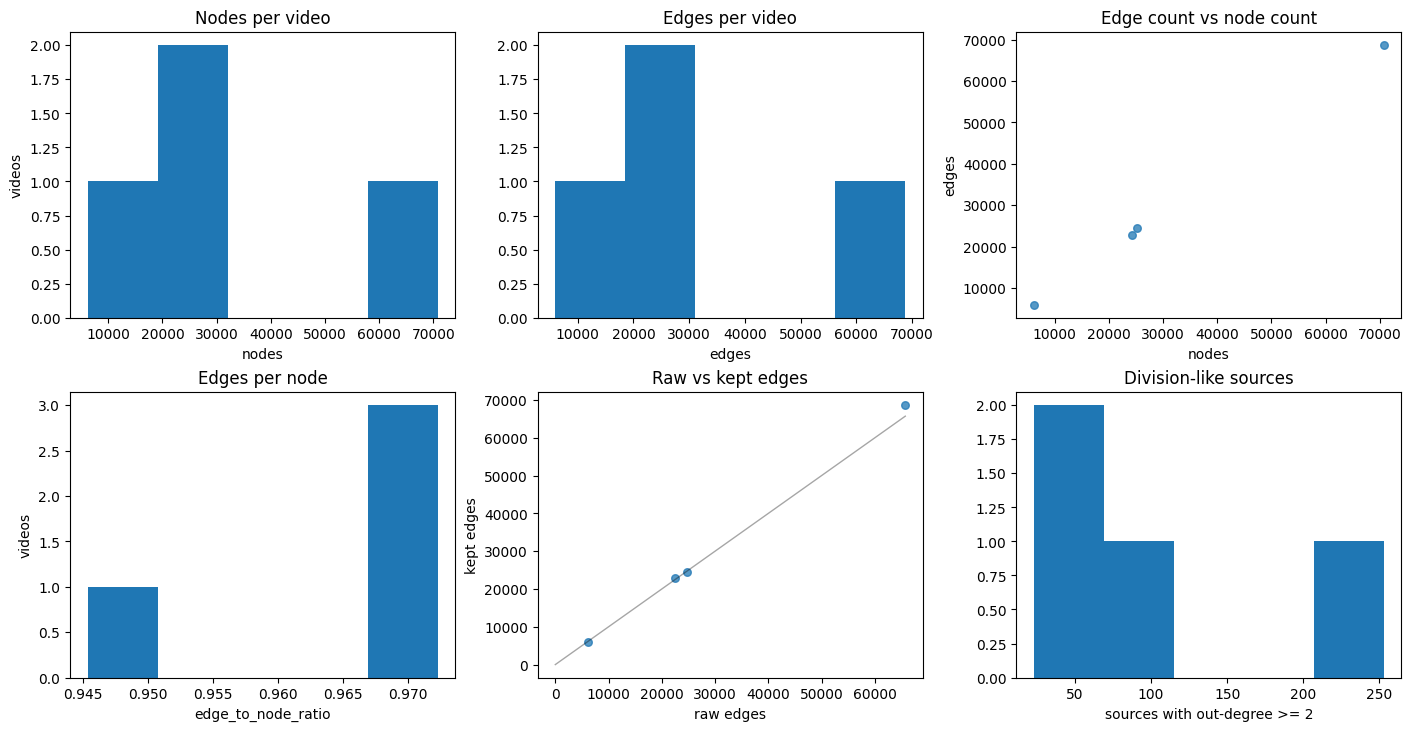

,dataset,raw_edges,edges,kept_edge_fraction,dropped_nonconsecutive_edges,dropped_long_edges,dropped_multi_parent_edges,dropped_multi_child_edges,dropped_division_edges,dropped_edges_total
1,44b6_0b24845f,22467,22869,1.017893,0,5,0,0,0,5
2,6bba_05b6850b,6146,5985,0.973804,0,4,0,0,0,4
0,44b6_0113de3b,24647,24536,0.995496,0,0,0,0,0,0
3,6bba_05db0fb1,65732,68795,1.046598,0,0,0,0,0,0


,dataset,nodes,edges,gap_added_nodes_frac,gap_candidates,gap_pairs_selected,gap_reused_existing,gap_inserted_synthetic,gap_added_nodes,gap_added_edges,gap_skipped_node_cap,gap_refined_synthetic,gap_refine_failed,gap_refine_rejected_shift,gap_close_effective_max_gap
1,44b6_0b24845f,24191,22869,0.036536,1514,1005,0,1005,1005,2010,0,1005,0,0,1
3,6bba_05db0fb1,70755,68795,0.013223,1642,951,0,951,951,1902,0,951,0,0,1
0,44b6_0113de3b,25264,24536,0.004348,139,112,0,112,112,224,0,112,0,0,1
2,6bba_05b6850b,6174,5985,0.007706,59,51,0,51,51,102,0,51,0,0,1


,gap_added_nodes_frac,gap_candidates,gap_pairs_selected,gap_reused_existing,gap_inserted_synthetic,gap_added_nodes,gap_added_edges,gap_skipped_node_cap,gap_refined_synthetic,gap_refine_failed,gap_refine_rejected_shift,gap_close_effective_max_gap
total,0.061814,3354.0,2119.0,0.0,2119.0,2119.0,4238.0,0.0,2119.0,0.0,0.0,4.0


,dataset,raw_nodes,raw_nodes_after_full_frame_fusion,nodes,raw_edges,edges,division_like_sources,edge_to_node_ratio,gap_added_nodes_frac,full_frame_enabled,...,short_track_nodes_removed,short_track_edges_removed,short_track_filter_skipped_all,linefit_smoothed_nodes,linefit_skipped_nodes,gap_close_effective_max_gap,predict_minutes_total,experiment_tag,dropped_edges_total,kept_edge_fraction
3,6bba_05db0fb1,71915,71918,70755,65732,68795,253,0.972299,0.013223,1,...,2092,1519,0,70735,20,1,6.103643,selected_30_deepcenter_500_last_sparse_gate_min7,0,1.046598
0,44b6_0113de3b,25760,25760,25264,24647,24536,42,0.971184,0.004348,1,...,602,442,0,25257,7,1,6.103643,selected_30_deepcenter_500_last_sparse_gate_min7,0,0.995496
1,44b6_0b24845f,27504,27507,24191,22467,22869,103,0.945352,0.036536,1,...,4278,2998,0,24163,28,1,6.103643,selected_30_deepcenter_500_last_sparse_gate_min7,5,1.017893
2,6bba_05b6850b,6618,6618,6174,6146,5985,23,0.969388,0.007706,1,...,493,348,0,6172,2,1,6.103643,selected_30_deepcenter_500_last_sparse_gate_min7,4,0.973804


,total
motion_relink_edges,122833
motion_relink_tight_edges,118941
motion_relink_relaxed_edges,3892
motion_relink_replaced_raw_edges,118983
motion_relink_fallback_raw,0
gap_added_nodes,2119
gap_added_edges,4238
gap2_candidates,0
gap2_pairs_selected,0
gap2_added_nodes,0


In [6]:
if RUN_OUTPUT_DIAGNOSTICS and len(stats):
    import matplotlib.pyplot as plt

    stats_view = stats.copy()
    stats_view["dropped_edges_total"] = 0
    for col in [
        "dropped_nonconsecutive_edges",
        "dropped_long_edges",
        "dropped_multi_parent_edges",
        "dropped_multi_child_edges",
        "dropped_division_edges",
    ]:
        if col in stats_view:
            stats_view["dropped_edges_total"] += stats_view[col].fillna(0)
    stats_view["kept_edge_fraction"] = stats_view["edges"] / stats_view["raw_edges"].clip(lower=1)

    fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.2), constrained_layout=True)
    axes = axes.ravel()

    axes[0].hist(stats_view["nodes"], bins=min(24, max(5, len(stats_view))))
    axes[0].set_title("Nodes per video")
    axes[0].set_xlabel("nodes")
    axes[0].set_ylabel("videos")

    axes[1].hist(stats_view["edges"], bins=min(24, max(5, len(stats_view))))
    axes[1].set_title("Edges per video")
    axes[1].set_xlabel("edges")

    axes[2].scatter(stats_view["nodes"], stats_view["edges"], s=30, alpha=0.75)
    axes[2].set_title("Edge count vs node count")
    axes[2].set_xlabel("nodes")
    axes[2].set_ylabel("edges")

    axes[3].hist(stats_view["edge_to_node_ratio"], bins=min(24, max(5, len(stats_view))))
    axes[3].set_title("Edges per node")
    axes[3].set_xlabel("edge_to_node_ratio")
    axes[3].set_ylabel("videos")

    axes[4].scatter(stats_view["raw_edges"], stats_view["edges"], s=30, alpha=0.75)
    axes[4].plot(
        [0, max(stats_view["raw_edges"].max(), 1)],
        [0, max(stats_view["raw_edges"].max(), 1)],
        color="black", linewidth=1, alpha=0.35,
    )
    axes[4].set_title("Raw vs kept edges")
    axes[4].set_xlabel("raw edges")
    axes[4].set_ylabel("kept edges")

    axes[5].hist(stats_view["division_like_sources"], bins=min(20, max(5, len(stats_view))))
    axes[5].set_title("Division-like sources")
    axes[5].set_xlabel("sources with out-degree >= 2")

    plt.show()

    drop_cols = [c for c in stats_view.columns if c.startswith("dropped_")]
    if drop_cols:
        drop_summary = stats_view[["dataset", "raw_edges", "edges", "kept_edge_fraction", *drop_cols]].copy()
        display(drop_summary.sort_values("dropped_edges_total", ascending=False).head(12))

    gap_cols = [c for c in stats_view.columns if c.startswith("gap_")]
    if gap_cols:
        gap_summary = stats_view[["dataset", "nodes", "edges", *gap_cols]].copy()
        display(gap_summary.sort_values("gap_added_edges", ascending=False).head(12))
        display(gap_summary[gap_cols].sum().to_frame("total").T)

    display(stats_view.sort_values("nodes", ascending=False).head(10))

    repair_cols = [
        "motion_relink_edges", "motion_relink_tight_edges", "motion_relink_relaxed_edges",
        "motion_relink_replaced_raw_edges", "motion_relink_fallback_raw",
        "gap_added_nodes", "gap_added_edges", "gap2_candidates",
        "gap2_pairs_selected", "gap2_added_nodes", "gap2_added_edges",
        "safe_division_candidates", "safe_divisions_added",
        "short_track_nodes_removed", "short_track_edges_removed",
    ]
    repair_cols = [col for col in repair_cols if col in stats_view.columns]
    if repair_cols:
        repair_summary = stats_view[repair_cols].sum().rename("total").to_frame()
        display(repair_summary)

